Loading FUTURE data from 5 CMIP6 models...
  ✓ Loaded MIROC6: 150 rows
  ✓ Loaded NorESM2-LM: 150 rows
  ✓ Loaded NorESM2-MM: 150 rows
  ✓ Loaded CMCC-CM2-SR5: 150 rows
  ✓ Loaded CMCC-ESM2: 150 rows

Loading PRESENT data from 5 CMIP6 models...
  ✓ Loaded MIROC6: 3418 rows
  ✓ Loaded NorESM2-LM: 3418 rows
  ✓ Loaded NorESM2-MM: 3418 rows
  ✓ Loaded CMCC-CM2-SR5: 3418 rows
  ✓ Loaded CMCC-ESM2: 3418 rows

Total FUTURE ensemble data: 750 rows from 5 models
Total PRESENT ensemble data: 17090 rows from 5 models

Northern Subtropics FUTURE data: 150 rows
Northern Subtropics PRESENT data: 1950 rows

=== FUTURE Ensemble Summary Statistics ===

Mean + Variability effects:
  Mean: -0.0333 t/ha
  Median: 0.0215 t/ha
  Std Dev: 0.2330 t/ha
  N: 150

Mean + Interdependence effects:
  Mean: 0.0282 t/ha
  Median: 0.0206 t/ha
  Std Dev: 0.1141 t/ha
  N: 150

Mean + Variability + Interdependence effects:
  Mean: -0.0051 t/ha
  Median: -0.0230 t/ha
  Std Dev: 0.2696 t/ha
  N: 150

=== PRESENT Ensemble 

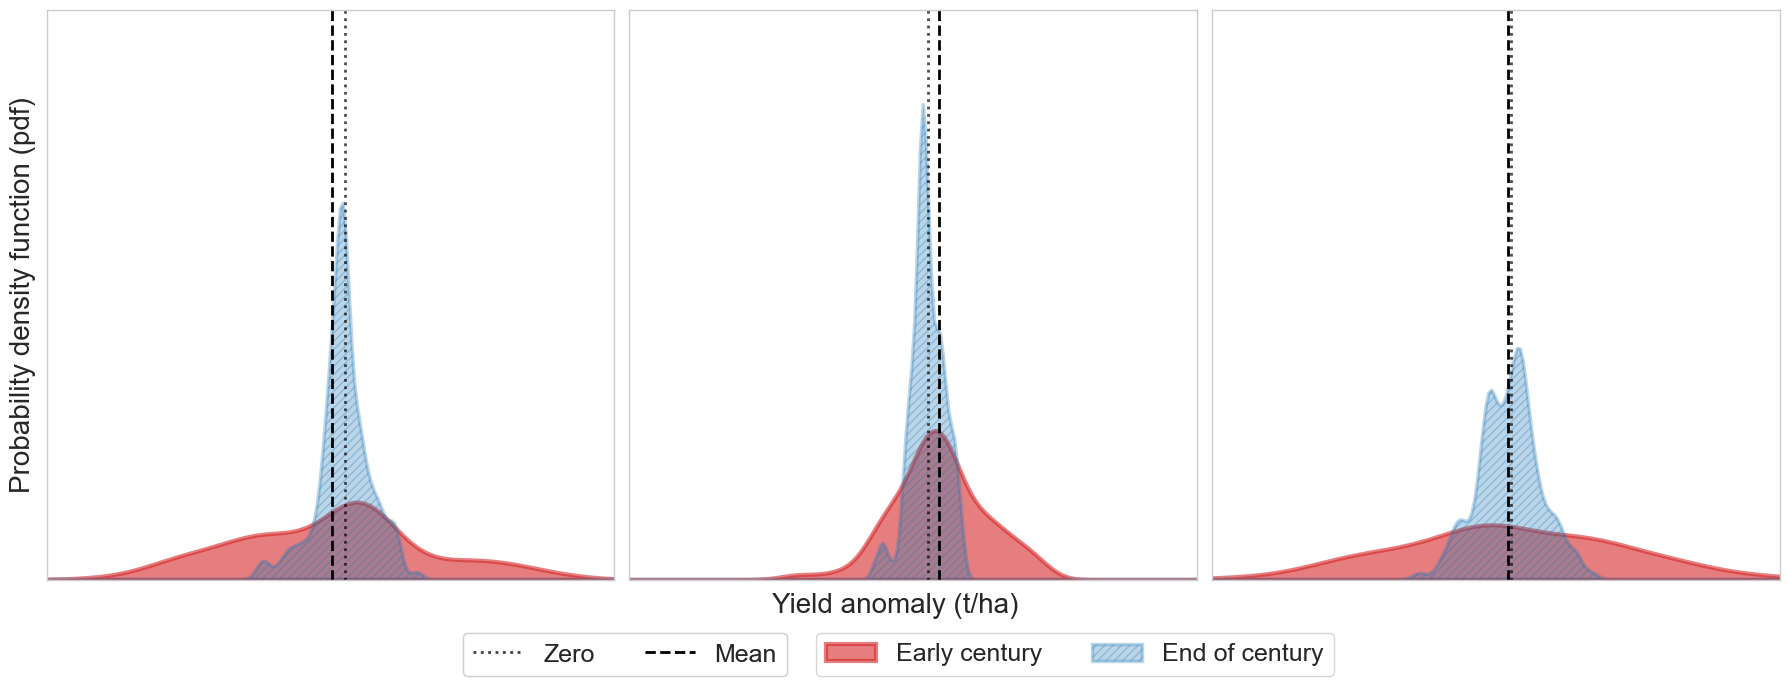

In [4]:
# Model ensemble - Present vs Future comparison

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")

def calculate_pdf(data, bins=50):
    """Calculate probability density function using kernel density estimation."""
    if len(data) < 2 or data.std() == 0:
        return np.array([data.mean()]), np.array([1.0])
    kde = stats.gaussian_kde(data, bw_method='scott')
    x_range = np.linspace(data.min(), data.max(), bins)
    pdf = kde(x_range)
    return x_range, pdf

# Define the 5 CSV files for FUTURE projections
future_file_configs = [
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_MIROC6_1.csv', 'model': 'MIROC6'},
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_NorESM2-LM_1.csv', 'model': 'NorESM2-LM'},
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_NorESM2-MM_1.csv', 'model': 'NorESM2-MM'},
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_CMCC-CM2-SR5_1.csv', 'model': 'CMCC-CM2-SR5'},
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_CMCC-ESM2_1.csv', 'model': 'CMCC-ESM2'}
]

# Define the 5 CSV files for PRESENT fitted values
present_file_configs = [
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/present_yield_fitted_MIROC6_1.csv', 'model': 'MIROC6'},
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/present_yield_fitted_NorESM2-LM_1.csv', 'model': 'NorESM2-LM'},
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/present_yield_fitted_NorESM2-MM_1.csv', 'model': 'NorESM2-MM'},
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/present_yield_fitted_CMCC-CM2-SR5_1.csv', 'model': 'CMCC-CM2-SR5'},
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/present_yield_fitted_CMCC-ESM2_1.csv', 'model': 'CMCC-ESM2'}
]

# Load and combine FUTURE data from all models
print("Loading FUTURE data from 5 CMIP6 models...")
future_df_list = []

for config in future_file_configs:
    try:
        df_temp = pd.read_csv(config['path'])
        df_temp['model'] = config['model']
        future_df_list.append(df_temp)
        print(f"  ✓ Loaded {config['model']}: {len(df_temp)} rows")
    except FileNotFoundError:
        print(f"  ✗ File not found: {config['path']}")
    except Exception as e:
        print(f"  ✗ Error loading {config['model']}: {str(e)}")

# Load and combine PRESENT data from all models
print("\nLoading PRESENT data from 5 CMIP6 models...")
present_df_list = []

for config in present_file_configs:
    try:
        df_temp = pd.read_csv(config['path'])
        df_temp['model'] = config['model']
        present_df_list.append(df_temp)
        print(f"  ✓ Loaded {config['model']}: {len(df_temp)} rows")
    except FileNotFoundError:
        print(f"  ✗ File not found: {config['path']}")
    except Exception as e:
        print(f"  ✗ Error loading {config['model']}: {str(e)}")

# Combine all model data
if len(future_df_list) == 0:
    raise ValueError("No FUTURE data files were successfully loaded!")
if len(present_df_list) == 0:
    raise ValueError("No PRESENT data files were successfully loaded!")

df_future_ensemble = pd.concat(future_df_list, ignore_index=True)
df_present_ensemble = pd.concat(present_df_list, ignore_index=True)

print(f"\nTotal FUTURE ensemble data: {len(df_future_ensemble)} rows from {len(future_df_list)} models")
print(f"Total PRESENT ensemble data: {len(df_present_ensemble)} rows from {len(present_df_list)} models")

# Filter for Northern Subtropics only
df_future_ns = df_future_ensemble[df_future_ensemble['region'] == 'R04_NS'].copy()
df_present_ns = df_present_ensemble[df_present_ensemble['region'] == 'R04_NS'].copy()

print(f"\nNorthern Subtropics FUTURE data: {len(df_future_ns)} rows")
print(f"Northern Subtropics PRESENT data: {len(df_present_ns)} rows")

# Convert numeric columns for both datasets
diff_cols = ['diff_M2_M1', 'diff_M3_M2', 'diff_M3_M1']
for col in diff_cols:
    if col in df_future_ns.columns:
        df_future_ns[col] = pd.to_numeric(df_future_ns[col], errors='coerce')
    if col in df_present_ns.columns:
        df_present_ns[col] = pd.to_numeric(df_present_ns[col], errors='coerce')

# Prepare results for CSV export
results_list = []

# Collect ensemble statistics for FUTURE
print("\n=== FUTURE Ensemble Summary Statistics ===")
for diff_info in [
    {'col': 'diff_M1_M2', 'label': 'Mean + Variability effects'},
    {'col': 'diff_M2_M3', 'label': 'Mean + Interdependence effects'},
    {'col': 'diff_M1_M3', 'label': 'Mean + Variability + Interdependence effects'}
]:



    diff_col = diff_info['col']
    if diff_col in df_future_ns.columns:
        data = df_future_ns[diff_col].dropna()
        
        result_row = {
            'Period': 'Future',
            'Model': 'Ensemble',
            'Effect': diff_info['label'],
            'Mean': data.mean(),
            'Median': data.median(),
            'Std_Dev': data.std(),
            'Min': data.min(),
            'Max': data.max(),
            'N': len(data)
        }
        results_list.append(result_row)
        
        print(f"\n{diff_info['label']}:")
        print(f"  Mean: {data.mean():.4f} t/ha")
        print(f"  Median: {data.median():.4f} t/ha")
        print(f"  Std Dev: {data.std():.4f} t/ha")
        print(f"  N: {len(data)}")

# Collect ensemble statistics for PRESENT
print("\n=== PRESENT Ensemble Summary Statistics ===")
for diff_info in [
    {'col': 'diff_M1_M2', 'label': 'Mean + Variability effects'},
    {'col': 'diff_M2_M3', 'label': 'Mean + Interdependence effects'},
    {'col': 'diff_M1_M3', 'label': 'Mean + Variability + Interdependence effects'}
]:
    diff_col = diff_info['col']
    if diff_col in df_present_ns.columns:
        data = df_present_ns[diff_col].dropna()
        
        result_row = {
            'Period': 'Present',
            'Model': 'Ensemble',
            'Effect': diff_info['label'],
            'Mean': data.mean(),
            'Median': data.median(),
            'Std_Dev': data.std(),
            'Min': data.min(),
            'Max': data.max(),
            'N': len(data)
        }
        results_list.append(result_row)
        
        print(f"\n{diff_info['label']}:")
        print(f"  Mean: {data.mean():.4f} t/ha")
        print(f"  Median: {data.median():.4f} t/ha")
        print(f"  Std Dev: {data.std():.4f} t/ha")
        print(f"  N: {len(data)}")

# Create DataFrame from results and save to CSV
results_df = pd.DataFrame(results_list)
csv_output_file = 'CMIP6_Ensemble_NorthernSubtropics_Present_vs_Future_Statistics.csv'
results_df.to_csv(csv_output_file, index=False)
print(f"\n✓ Statistics saved to: {csv_output_file}")

# Determine global x-axis limits across all subplots
all_x_mins = []
all_x_maxs = []

diff_cols_plot = ['diff_M1_M2', 'diff_M2_M3', 'diff_M1_M3']
for col in diff_cols_plot:
    if col in df_present_ns.columns and col in df_future_ns.columns:
        present_data = df_present_ns[col].dropna().values
        future_data = df_future_ns[col].dropna().values
        
        if len(present_data) > 0:
            all_x_mins.append(present_data.min())
            all_x_maxs.append(present_data.max())
        if len(future_data) > 0:
            all_x_mins.append(future_data.min())
            all_x_maxs.append(future_data.max())

# Calculate global x-axis range with some padding
x_min_global = min(all_x_mins) - 0.05 * abs(min(all_x_mins))
x_max_global = max(all_x_maxs) + 0.05 * abs(max(all_x_maxs))

print(f"\nGlobal x-axis range: [{x_min_global:.4f}, {x_max_global:.4f}]")

# Create the PDF plot with shared y-axis
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Subplot configurations
diff_configs = [
    {'col': 'diff_M1_M2', 'label': 'Mean + Variability effects'},
    {'col': 'diff_M2_M3', 'label': 'Mean + Interdependence effects'},
    {'col': 'diff_M1_M3', 'label': 'Mean + Variability + Interdependence effects'}
]

# Define colors for periods
color_present = '#1f77b4'  # Blue
color_future = '#d62728'   # Red

# Store handles and labels for shared legend
legend_handles_ref = []
legend_labels_ref = ['Zero', 'Mean']
legend_handles_period = []
legend_labels_period = []

# Track max PDF values for y-axis scaling
max_pdf_values = []

for idx, diff_info in enumerate(diff_configs):
    ax = axes[idx]
    diff_col = diff_info['col']
    
    # Get PRESENT data (all models combined)
    present_data = df_present_ns[diff_col].dropna().values
    
    # Get FUTURE data (all models combined)
    future_data = df_future_ns[diff_col].dropna().values
    
    if len(future_data) > 0 or len(present_data) > 0:

        # Calculate and plot FUTURE PDF (red filled area - more prominent)
        if len(future_data) >= 2 and future_data.std() > 0:
            kde_future = stats.gaussian_kde(future_data, bw_method='scott')
            x = np.linspace(x_min_global, x_max_global, 200)
            pdf_future = kde_future(x)
            
            max_pdf_values.append(pdf_future.max())
            
            # Plot future as red filled area - more opaque and thicker edge
            future_fill = ax.fill_between(x, pdf_future, alpha=0.6, color=color_future, 
                                        edgecolor=color_future, linewidth=3, label='Future')

        # Calculate and plot PRESENT PDF (blue hatching with light fill)
        if len(present_data) >= 2 and present_data.std() > 0:
            kde_present = stats.gaussian_kde(present_data, bw_method='scott')
            x = np.linspace(x_min_global, x_max_global, 200)
            pdf_present = kde_present(x)
            
            max_pdf_values.append(pdf_present.max())
            
            # Plot present as blue hatching with light blue fill
            present_fill = ax.fill_between(x, pdf_present, alpha=0.3, 
                                        edgecolor=color_present, linewidth=2.5,
                                        hatch='////', facecolor=color_present, label='Present')
        
        # Add vertical line at zero
        line_zero = ax.axvline(x=0, color='black', linestyle=':', linewidth=2, alpha=0.7)
        
        # Add mean lines (for future data)
        if len(future_data) > 0:
            mean_future = future_data.mean()
            line_mean = ax.axvline(x=mean_future, color='black', linestyle='--', linewidth=2)
        
        # Collect legend handles only from the first subplot
        if idx == 0:
            legend_handles_ref = [line_zero, line_mean]
            if len(future_data) >= 2:
                legend_handles_period.append(future_fill)
            if len(present_data) >= 2:
                legend_handles_period.append(present_fill)
            legend_labels_period = ['Early century', 'End of century']
        
        # Formatting
        #ax.set_title(diff_info['label'], fontsize=18, fontweight='bold', pad=15)
        
        # Set global x-axis limits
        ax.set_xlim(x_min_global, x_max_global)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        
        # Only set ylabel for the first subplot
        if idx == 0:
            ax.set_ylabel('Probability density function (pdf)', fontsize=20, fontweight='normal')
        
        ax.grid(False)
        ax.tick_params(labelsize=14)
    else:
        ax.text(0.5, 0.5, 'No data available', 
               transform=ax.transAxes, ha='center', va='center', fontsize=16)
        ax.set_xlim(x_min_global, x_max_global)

# Set shared y-axis limit based on maximum PDF value with some padding
if max_pdf_values:
    y_max = max(max_pdf_values) * 1.2  # 10% padding
    for ax in axes:
        ax.set_ylim(0, y_max)

print(f"Y-axis range: [0, {y_max:.4f}]")

# Add two separate legends
# Legend 1: Reference lines (zero and mean)
legend1 = fig.legend(legend_handles_ref, legend_labels_ref, loc='center', 
                     bbox_to_anchor=(0.35, -0.1), ncol=2, fontsize=18, 
                     frameon=True)

# Legend 2: Period (future vs present)
legend2 = fig.legend(legend_handles_period, legend_labels_period, loc='center', 
                     bbox_to_anchor=(0.6, -0.1), ncol=2, fontsize=18, 
                     frameon=True)

# Add the first legend manually since fig.legend() only keeps the last one
ax = fig.gca()
ax.add_artist(legend1)

plt.tight_layout()

# Add shared x-axis label centered below all subplots
fig.text(0.5, -0.03, 'Yield anomaly (t/ha)', ha='center', fontsize=20, fontweight='normal')

# Save plot
plot_output_file = 'CMIP6_Ensemble_NorthernSubtropics_Present_vs_Future.png'
plt.savefig(plot_output_file, dpi=800, bbox_inches='tight')
print(f"✓ Plot saved to: {plot_output_file}")

plt.show()

Loading data...
Loaded 3418 rows
Columns: ['region', 'year', 'E_mean', 'SM_mean', 'E_sd', 'SM_sd', 'dep_ESM', 'Area', 'yield', 'log_yield', 'log_yield_M1', 'log_yield_M2', 'log_yield_M3', 'yield_M1', 'yield_M2', 'yield_M3', 'diff_M2_M3', 'diff_M1_M3', 'diff_M1_M2']

Northern Subtropics data: 390 rows

Yield difference columns:
  yield_M2: 390 valid values, mean=3.173, std=0.076
  diff_M2_M3: 390 valid values, mean=-0.000, std=0.040
  yield_M3: 390 valid values, mean=3.173, std=0.087

✓ Saved: MIROC6_NorthernSubtropics_Present.png


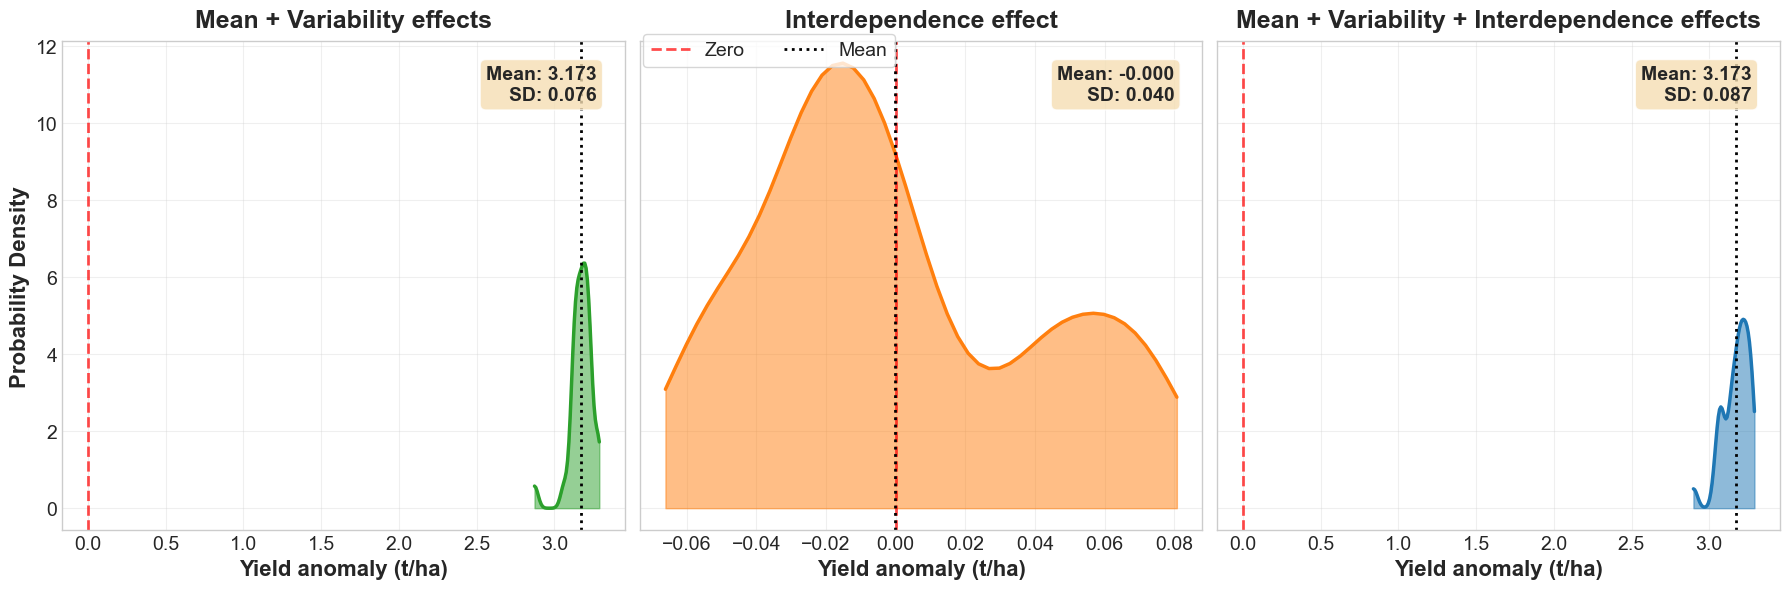


=== Summary Statistics ===

Mean + Variability effects:
  Mean: 3.1729 t/ha
  Median: 3.1810 t/ha
  Std Dev: 0.0764 t/ha
  Min: 2.8719 t/ha
  Max: 3.2885 t/ha
  N: 390

Interdependence effect:
  Mean: -0.0003 t/ha
  Median: -0.0093 t/ha
  Std Dev: 0.0401 t/ha
  Min: -0.0661 t/ha
  Max: 0.0808 t/ha
  N: 390

Mean + Variability + Interdependence effects:
  Mean: 3.1732 t/ha
  Median: 3.1876 t/ha
  Std Dev: 0.0873 t/ha
  Min: 2.8980 t/ha
  Max: 3.2905 t/ha
  N: 390


In [13]:
# Present 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")

def calculate_pdf(data, bins=50):
    """Calculate probability density function using kernel density estimation."""
    if len(data) < 2 or data.std() == 0:
        return np.array([data.mean()]), np.array([1.0])
    kde = stats.gaussian_kde(data, bw_method='scott')
    x_range = np.linspace(data.min(), data.max(), bins)
    pdf = kde(x_range)
    return x_range, pdf

# Load data
print("Loading data...")
df = pd.read_csv('/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/present_yield_fitted_rice_MIROC6.csv')

print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")

# Filter for Northern Subtropics only
df_ns = df[df['region'] == 'R04_NS'].copy()

print(f"\nNorthern Subtropics data: {len(df_ns)} rows")

# Convert numeric columns
diff_cols = ['yield_M2', 'diff_M2_M3', 'yield_M3']
for col in diff_cols:
    if col in df_ns.columns:
        df_ns[col] = pd.to_numeric(df_ns[col], errors='coerce')

# Check data availability
print("\nYield difference columns:")
for col in diff_cols:
    if col in df_ns.columns:
        valid_data = df_ns[col].dropna()
        print(f"  {col}: {len(valid_data)} valid values, mean={valid_data.mean():.3f}, std={valid_data.std():.3f}")

# Create the PDF plot with shared y-axis
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Reordered sequence with colors defined for all items
diff_configs = [
    {'col': 'yield_M2', 'label': 'Mean + Variability effects', 'color': '#2ca02c'},
    {'col': 'diff_M2_M3', 'label': 'Interdependence effect', 'color': '#ff7f0e'},
    {'col': 'yield_M3', 'label': 'Mean + Variability + Interdependence effects', 'color': '#1f77b4'}
]

# Store handles and labels for shared legend
legend_handles = []
legend_labels = []

for idx, diff_info in enumerate(diff_configs):
    ax = axes[idx]
    diff_col = diff_info['col']
    
    # Get data
    data = df_ns[diff_col].dropna().values
    
    if len(data) > 0:
        # Calculate PDF
        x, pdf = calculate_pdf(data)
        
        # Plot
        ax.fill_between(x, pdf, alpha=0.5, color=diff_info['color'])
        ax.plot(x, pdf, color=diff_info['color'], linewidth=2.5)
        
        # Add vertical line at zero
        line_zero = ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
        
        # Add mean line
        mean_val = data.mean()
        line_mean = ax.axvline(x=mean_val, color='black', linestyle=':', linewidth=2)
        
        # Collect legend handles only from the first subplot
        if idx == 0:
            legend_handles = [line_zero, line_mean]
            legend_labels = ['Zero', 'Mean']
        
        # Statistics text
        stats_text = f'Mean: {mean_val:.3f}\nSD: {data.std():.3f}'
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
               fontsize=14, fontweight='bold')
        
        # Formatting
        ax.set_title(diff_info['label'], fontsize=18, fontweight='bold', pad=10)
        ax.set_xlabel('Yield anomaly (t/ha)', fontsize=16, fontweight='bold')
        
        # Only set ylabel for the first subplot
        if idx == 0:
            ax.set_ylabel('Probability Density', fontsize=16, fontweight='bold')
        
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=14)
    else:
        ax.text(0.5, 0.5, 'No data available', 
               transform=ax.transAxes, ha='center', va='center', fontsize=14)

# Add single legend for the entire figure
fig.legend(legend_handles, legend_labels, loc='upper center', 
          bbox_to_anchor=(0.43, 0.95), ncol=2, fontsize=14, frameon=True)

plt.tight_layout()

# Save
output_file = 'MIROC6_NorthernSubtropics_Present.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_file}")

plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
for diff_info in diff_configs:
    diff_col = diff_info['col']
    if diff_col in df_ns.columns:
        data = df_ns[diff_col].dropna()
        print(f"\n{diff_info['label']}:")
        print(f"  Mean: {data.mean():.4f} t/ha")
        print(f"  Median: {data.median():.4f} t/ha")
        print(f"  Std Dev: {data.std():.4f} t/ha")
        print(f"  Min: {data.min():.4f} t/ha")
        print(f"  Max: {data.max():.4f} t/ha")
        print(f"  N: {len(data)}")

Loading data from 5 CMIP6 models...
  ✓ Loaded MIROC6: 150 rows
  ✓ Loaded NorESM2-LM: 150 rows
  ✓ Loaded NorESM2-MM: 150 rows
  ✓ Loaded CMCC-CM2-SR5: 150 rows
  ✓ Loaded CMCC-ESM2: 150 rows

Total ensemble data: 750 rows from 5 models
Columns: ['region', 'year', 'E_mean', 'SM_mean', 'E_sd', 'SM_sd', 'dep_ESM', 'log_yield_M1', 'log_yield_M2', 'log_yield_M3', 'yield_M1', 'yield_M2', 'yield_M3', 'diff_M2_M3', 'diff_M1_M3', 'diff_M1_M2', 'model']

Northern Subtropics ensemble data: 150 rows
Models included: ['MIROC6' 'NorESM2-LM' 'NorESM2-MM' 'CMCC-CM2-SR5' 'CMCC-ESM2']
Rows per model:
  MIROC6: 30
  NorESM2-LM: 30
  NorESM2-MM: 30
  CMCC-CM2-SR5: 30
  CMCC-ESM2: 30

Yield difference columns (ensemble):
  diff_M1_M2: 150 valid values, mean=-0.033, std=0.233
  diff_M2_M3: 150 valid values, mean=0.028, std=0.114
  diff_M1_M3: 150 valid values, mean=-0.005, std=0.270

=== Ensemble Summary Statistics ===

Mean + Variability effects:
  Mean: 3.7317 t/ha
  Median: 3.5733 t/ha
  Std Dev: 0.522

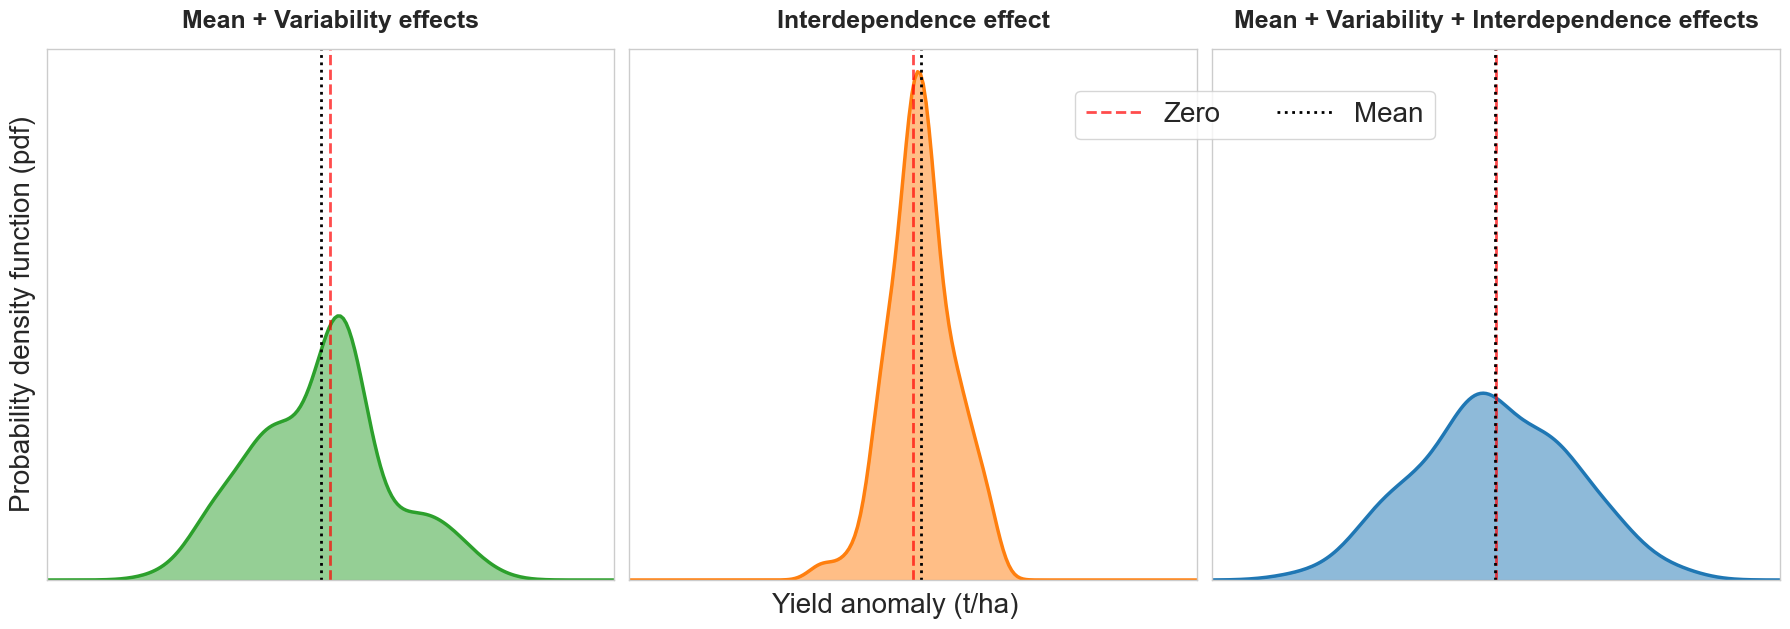

In [8]:
# Model ensamble

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")

def calculate_pdf(data, bins=50):
    """Calculate probability density function using kernel density estimation."""
    if len(data) < 2 or data.std() == 0:
        return np.array([data.mean()]), np.array([1.0])
    kde = stats.gaussian_kde(data, bw_method='scott')
    x_range = np.linspace(data.min(), data.max(), bins)
    pdf = kde(x_range)
    return x_range, pdf

# Define the 5 CSV files explicitly
file_configs = [
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_MIROC6.csv', 'model': 'MIROC6'},
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-LM.csv', 'model': 'NorESM2-LM'},
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-MM.csv', 'model': 'NorESM2-MM'},
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_CMCC-CM2-SR5.csv', 'model': 'CMCC-CM2-SR5'},
    {'path': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_CMCC-ESM2.csv', 'model': 'CMCC-ESM2'}
]

# Load and combine data from all models
print("Loading data from 5 CMIP6 models...")
df_list = []

for config in file_configs:
    try:
        df_temp = pd.read_csv(config['path'])
        df_temp['model'] = config['model']  # Add model identifier
        df_list.append(df_temp)
        print(f"  ✓ Loaded {config['model']}: {len(df_temp)} rows")
    except FileNotFoundError:
        print(f"  ✗ File not found: {config['path']}")
    except Exception as e:
        print(f"  ✗ Error loading {config['model']}: {str(e)}")

# Combine all model data
if len(df_list) == 0:
    raise ValueError("No data files were successfully loaded!")

df_ensemble = pd.concat(df_list, ignore_index=True)
print(f"\nTotal ensemble data: {len(df_ensemble)} rows from {len(df_list)} models")
print(f"Columns: {list(df_ensemble.columns)}")

# Filter for Northern Subtropics only
df_ns = df_ensemble[df_ensemble['region'] == 'R04_NS'].copy()

print(f"\nNorthern Subtropics ensemble data: {len(df_ns)} rows")
print(f"Models included: {df_ns['model'].unique()}")
print(f"Rows per model:")
for config in file_configs:
    model = config['model']
    if model in df_ns['model'].values:
        print(f"  {model}: {len(df_ns[df_ns['model'] == model])}")

# Convert numeric columns
diff_cols = ['diff_M1_M2', 'diff_M2_M3', 'diff_M1_M3']
for col in diff_cols:
    if col in df_ns.columns:
        df_ns[col] = pd.to_numeric(df_ns[col], errors='coerce')

# Check data availability
print("\nYield difference columns (ensemble):")
for col in diff_cols:
    if col in df_ns.columns:
        valid_data = df_ns[col].dropna()
        print(f"  {col}: {len(valid_data)} valid values, mean={valid_data.mean():.3f}, std={valid_data.std():.3f}")

# Prepare results for CSV export
results_list = []

# Collect ensemble statistics
print("\n=== Ensemble Summary Statistics ===")
for diff_info in [
    {'col': 'yield_M2', 'label': 'Mean + Variability effects'},
    {'col': 'diff_M2_M3', 'label': 'Interdependence effect'},
    {'col': 'yield_M1', 'label': 'Mean + Variability + Interdependence effects'}
]:
    diff_col = diff_info['col']
    if diff_col in df_ns.columns:
        data = df_ns[diff_col].dropna()
        
        result_row = {
            'Model': 'Ensemble',
            'Effect': diff_info['label'],
            'Mean': data.mean(),
            'Median': data.median(),
            'Std_Dev': data.std(),
            'Min': data.min(),
            'Max': data.max(),
            'N': len(data)
        }
        results_list.append(result_row)
        
        print(f"\n{diff_info['label']}:")
        print(f"  Mean: {data.mean():.4f} t/ha")
        print(f"  Median: {data.median():.4f} t/ha")
        print(f"  Std Dev: {data.std():.4f} t/ha")
        print(f"  Min: {data.min():.4f} t/ha")
        print(f"  Max: {data.max():.4f} t/ha")
        print(f"  N: {len(data)}")

# Collect statistics by individual model
print("\n=== Statistics by Individual Model ===")
for config in file_configs:
    model = config['model']
    if model in df_ns['model'].values:
        print(f"\n{model}:")
        df_model = df_ns[df_ns['model'] == model]
        
        for diff_info in [
            {'col': 'yield_M2', 'label': 'Mean + Variability effects'},
            {'col': 'diff_M2_M3', 'label': 'Interdependence effect'},
            {'col': 'yield_M1', 'label': 'Mean + Variability + Interdependence effects'}
        ]:
            diff_col = diff_info['col']
            if diff_col in df_model.columns:
                data = df_model[diff_col].dropna()
                if len(data) > 0:
                    result_row = {
                        'Model': model,
                        'Effect': diff_info['label'],
                        'Mean': data.mean(),
                        'Median': data.median(),
                        'Std_Dev': data.std(),
                        'Min': data.min(),
                        'Max': data.max(),
                        'N': len(data)
                    }
                    results_list.append(result_row)
                    
                    print(f"  {diff_info['label']}: Mean={data.mean():.4f}, SD={data.std():.4f}, N={len(data)}")

# Create DataFrame from results and save to CSV
results_df = pd.DataFrame(results_list)
csv_output_file = 'CMIP6_Ensemble_NorthernSubtropics_Statistics.csv'
results_df.to_csv(csv_output_file, index=False)
print(f"\n✓ Statistics saved to: {csv_output_file}")

# Create the PDF plot with shared y-axis
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Reordered sequence: Variability effect, Interdependence effect, Combined effect
diff_configs = [
    {'col': 'diff_M1_M2', 'label': 'Mean + Variability effects', 'color': '#2ca02c'},
    {'col': 'diff_M2_M3', 'label': 'Interdependence effect', 'color': '#ff7f0e'},
    {'col': 'diff_M1_M3', 'label': 'Mean + Variability + Interdependence effects', 'color': '#1f77b4'}
]

# Set fixed x-axis limits for all subplots
x_min, x_max = -1, 1.0

# Store handles and labels for shared legend
legend_handles = []
legend_labels = []

for idx, diff_info in enumerate(diff_configs):
    ax = axes[idx]
    diff_col = diff_info['col']
    
    # Get ensemble data (all models combined)
    data = df_ns[diff_col].dropna().values
    
    if len(data) > 0:
        # Calculate PDF using the fixed x-range
        if len(data) >= 2 and data.std() > 0:
            kde = stats.gaussian_kde(data, bw_method='scott')
            x = np.linspace(x_min, x_max, 200)
            pdf = kde(x)
        else:
            x = np.array([data.mean()])
            pdf = np.array([1.0])
        
        # Plot ensemble PDF
        ax.fill_between(x, pdf, alpha=0.5, color=diff_info['color'])
        ax.plot(x, pdf, color=diff_info['color'], linewidth=2.5, label='Ensemble')
        
        # Add vertical line at zero
        line_zero = ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
        
        # Add mean line
        mean_val = data.mean()
        line_mean = ax.axvline(x=mean_val, color='black', linestyle=':', linewidth=2)
        
        # Collect legend handles only from the first subplot
        if idx == 0:
            legend_handles = [line_zero, line_mean]
            legend_labels = ['Zero', 'Mean']
        
        # Formatting
        ax.set_title(diff_info['label'], fontsize=18, fontweight='bold', pad=15)
        
        # Set fixed x-axis limits
        ax.set_xlim(x_min, x_max)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        
        # Only set ylabel for the first subplot
        if idx == 0:
            ax.set_ylabel('Probability density function (pdf)', fontsize=20, fontweight='normal')
        
        ax.grid(False)
        ax.set_ylim(0, 4)  # Adjust the max value as needed
        ax.tick_params(labelsize=14)
    else:
        ax.text(0.5, 0.5, 'No data available', 
               transform=ax.transAxes, ha='center', va='center', fontsize=16)
        ax.set_xlim(x_min, x_max)

# Add single legend for the entire figure
fig.legend(legend_handles, legend_labels, loc='center', 
          bbox_to_anchor=(0.7, 0.8), ncol=2, fontsize=20, frameon=True)

plt.tight_layout()

# Add shared x-axis label centered below all subplots
fig.text(0.5, -0.03, 'Yield anomaly (t/ha)', ha='center', fontsize=20, fontweight='normal')

# Save plot
plot_output_file = 'CMIP6_Ensemble_NorthernSubtropics.png'
plt.savefig(plot_output_file, dpi=800, bbox_inches='tight')
print(f"✓ Plot saved to: {plot_output_file}")

plt.show()

Loading NorESM2-LM data...
Loaded 150 rows
Columns: ['region', 'year', 'E_mean', 'SM_mean', 'E_sd', 'SM_sd', 'dep_ESM', 'log_yield_M1', 'log_yield_M2', 'log_yield_M3', 'yield_M1', 'yield_M2', 'yield_M3', 'diff_M2_M3', 'diff_M1_M3', 'diff_M1_M2']

Northern Subtropics data: 30 rows

Yield difference columns:
  diff_M1_M2: 30 valid values, mean=-0.235, std=0.088
  diff_M2_M3: 30 valid values, mean=-0.011, std=0.140
  diff_M1_M3: 30 valid values, mean=-0.246, std=0.188

✓ Saved: NorESM2-LM_NorthernSubtropics.png


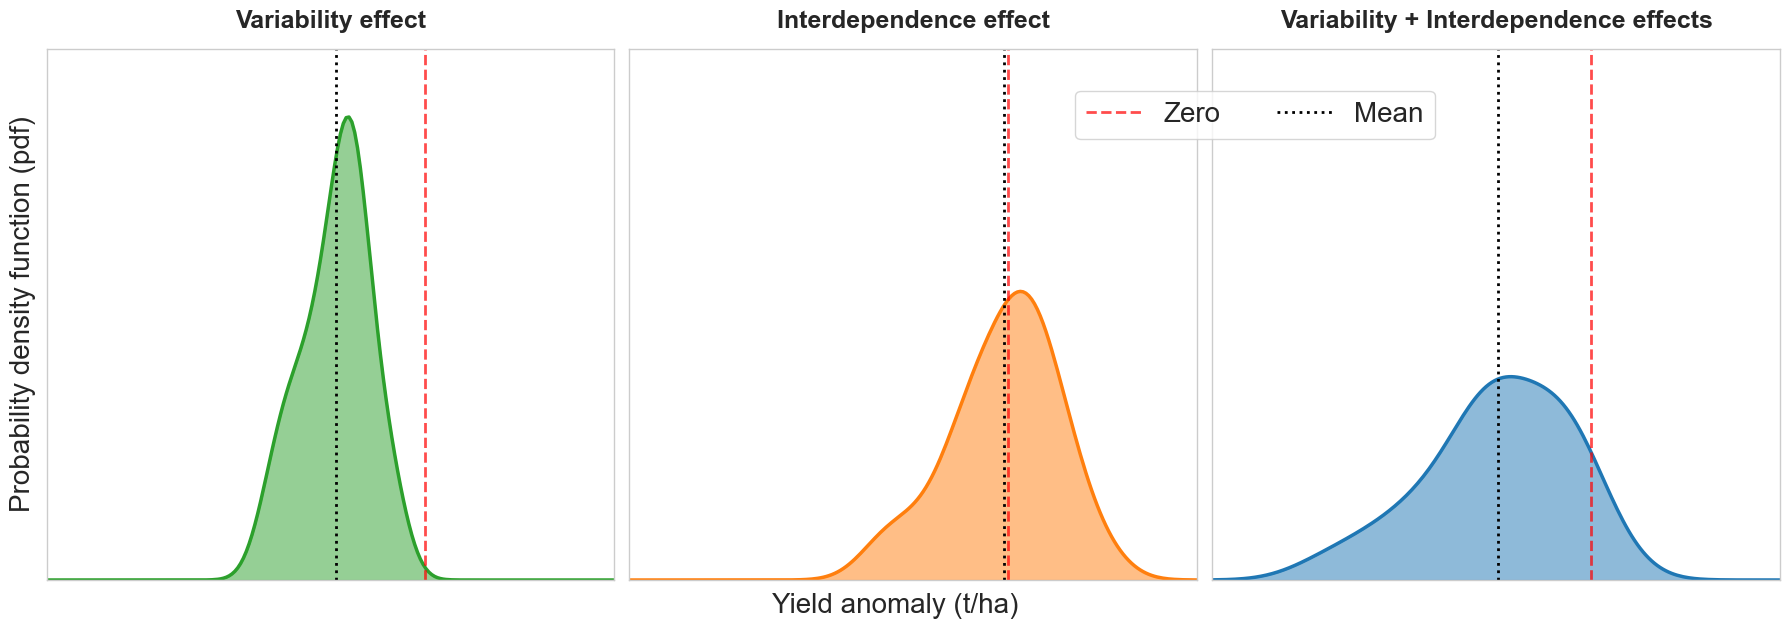


=== Summary Statistics ===

Variability effect:
  Mean: -0.2352 t/ha
  Median: -0.2195 t/ha
  Std Dev: 0.0882 t/ha
  Min: -0.4216 t/ha
  Max: -0.0822 t/ha
  N: 30

Interdependence effect:
  Mean: -0.0107 t/ha
  Median: 0.0100 t/ha
  Std Dev: 0.1401 t/ha
  Min: -0.3377 t/ha
  Max: 0.2517 t/ha
  N: 30

Variability + Interdependence effects:
  Mean: -0.2459 t/ha
  Median: -0.2480 t/ha
  Std Dev: 0.1881 t/ha
  Min: -0.7081 t/ha
  Max: 0.0527 t/ha
  N: 30


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")

def calculate_pdf(data, bins=50):
    """Calculate probability density function using kernel density estimation."""
    if len(data) < 2 or data.std() == 0:
        return np.array([data.mean()]), np.array([1.0])
    kde = stats.gaussian_kde(data, bw_method='scott')
    x_range = np.linspace(data.min(), data.max(), bins)
    pdf = kde(x_range)
    return x_range, pdf

# Load NorESM2-LM data
print("Loading NorESM2-LM data...")
df = pd.read_csv('/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-LM.csv')

print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")

# Filter for Northern Subtropics only
df_ns = df[df['region'] == 'R04_NS'].copy()

print(f"\nNorthern Subtropics data: {len(df_ns)} rows")

# Convert numeric columns
diff_cols = ['diff_M1_M2', 'diff_M2_M3', 'diff_M1_M3']
for col in diff_cols:
    if col in df_ns.columns:
        df_ns[col] = pd.to_numeric(df_ns[col], errors='coerce')

# Check data availability
print("\nYield difference columns:")
for col in diff_cols:
    if col in df_ns.columns:
        valid_data = df_ns[col].dropna()
        print(f"  {col}: {len(valid_data)} valid values, mean={valid_data.mean():.3f}, std={valid_data.std():.3f}")

# Create the PDF plot with shared y-axis
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Reordered sequence: Mean effect, Variability effect, Coupling effect
diff_configs = [
    {'col': 'diff_M1_M2', 'label': 'Variability effect', 'color': '#2ca02c'},
    {'col': 'diff_M2_M3', 'label': 'Interdependence effect', 'color': '#ff7f0e'},
    {'col': 'diff_M1_M3', 'label': 'Variability + Interdependence effects', 'color': '#1f77b4'}
]

# Set fixed x-axis limits for all subplots
x_min, x_max = -1, 0.5

# Store handles and labels for shared legend
legend_handles = []
legend_labels = []

for idx, diff_info in enumerate(diff_configs):
    ax = axes[idx]
    diff_col = diff_info['col']
    
    # Get data
    data = df_ns[diff_col].dropna().values
    
    if len(data) > 0:
        # Calculate PDF using the fixed x-range
        if len(data) >= 2 and data.std() > 0:
            kde = stats.gaussian_kde(data, bw_method='scott')
            x = np.linspace(x_min, x_max, 200)
            pdf = kde(x)
        else:
            x = np.array([data.mean()])
            pdf = np.array([1.0])
        
        # Plot
        ax.fill_between(x, pdf, alpha=0.5, color=diff_info['color'])
        ax.plot(x, pdf, color=diff_info['color'], linewidth=2.5)
        
        # Add vertical line at zero
        line_zero = ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
        
        # Add mean line
        mean_val = data.mean()
        line_mean = ax.axvline(x=mean_val, color='black', linestyle=':', linewidth=2)
        
        # Collect legend handles only from the first subplot
        if idx == 0:
            legend_handles = [line_zero, line_mean]
            legend_labels = ['Zero', 'Mean']
        
        # Statistics text
        #stats_text = f'Mean: {mean_val:.3f}\nSD: {data.std():.3f}'
        #ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
        #       verticalalignment='top', horizontalalignment='right',
        #       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        #       fontsize=14, fontweight='bold')
        
        # Formatting
        ax.set_title(diff_info['label'], fontsize=18, fontweight='bold', pad=15)
        #ax.set_xlabel('Yield difference (t/ha)', fontsize=16, fontweight='normal')
        
        # Set fixed x-axis limits
        ax.set_xlim(x_min, x_max)

        ax.set_xticklabels([])
        ax.set_yticklabels([])
        
        # Only set ylabel for the first subplot
        if idx == 0:
            ax.set_ylabel('Probability density function (pdf)', fontsize=20, fontweight='normal')
        
        #ax.grid(True, alpha=0.3)
        ax.grid(False)
        ax.set_ylim(0, 5)  # Adjust the max value as needed
        ax.tick_params(labelsize=14)
    else:
        ax.text(0.5, 0.5, 'No data available', 
               transform=ax.transAxes, ha='center', va='center', fontsize=16)
        ax.set_xlim(x_min, x_max)

# Add single legend for the entire figure
fig.legend(legend_handles, legend_labels, loc='center', 
          bbox_to_anchor=(0.7, 0.8), ncol=2, fontsize=20, frameon=True)

plt.tight_layout()

# Add shared x-axis label centered below all subplots
fig.text(0.5, -0.03, 'Yield anomaly (t/ha)', ha='center', fontsize=20, fontweight='normal')

# Save
output_file = 'NorESM2-LM_NorthernSubtropics.png'
plt.savefig(output_file, dpi=800, bbox_inches='tight')
print(f"\n✓ Saved: {output_file}")

plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
for diff_info in diff_configs:
    diff_col = diff_info['col']
    if diff_col in df_ns.columns:
        data = df_ns[diff_col].dropna()
        print(f"\n{diff_info['label']}:")
        print(f"  Mean: {data.mean():.4f} t/ha")
        print(f"  Median: {data.median():.4f} t/ha")
        print(f"  Std Dev: {data.std():.4f} t/ha")
        print(f"  Min: {data.min():.4f} t/ha")
        print(f"  Max: {data.max():.4f} t/ha")
        print(f"  N: {len(data)}")

Loading NorESM2-LM data...
Loaded 150 rows
Columns: ['region', 'year', 'E_mean', 'SM_mean', 'E_sd', 'SM_sd', 'dep_ESM', 'log_yield_M1', 'log_yield_M2', 'log_yield_M3', 'yield_M1', 'yield_M2', 'yield_M3', 'diff_M2_M3', 'diff_M1_M3', 'diff_M1_M2']

Northern Subtropics data: 30 rows

Yield difference columns:
  diff_M1_M2: 30 valid values, mean=-0.235, std=0.088
  diff_M2_M3: 30 valid values, mean=-0.011, std=0.140
  diff_M1_M3: 30 valid values, mean=-0.246, std=0.188

✓ Saved: NorESM2-LM_NorthernSubtropics1.png


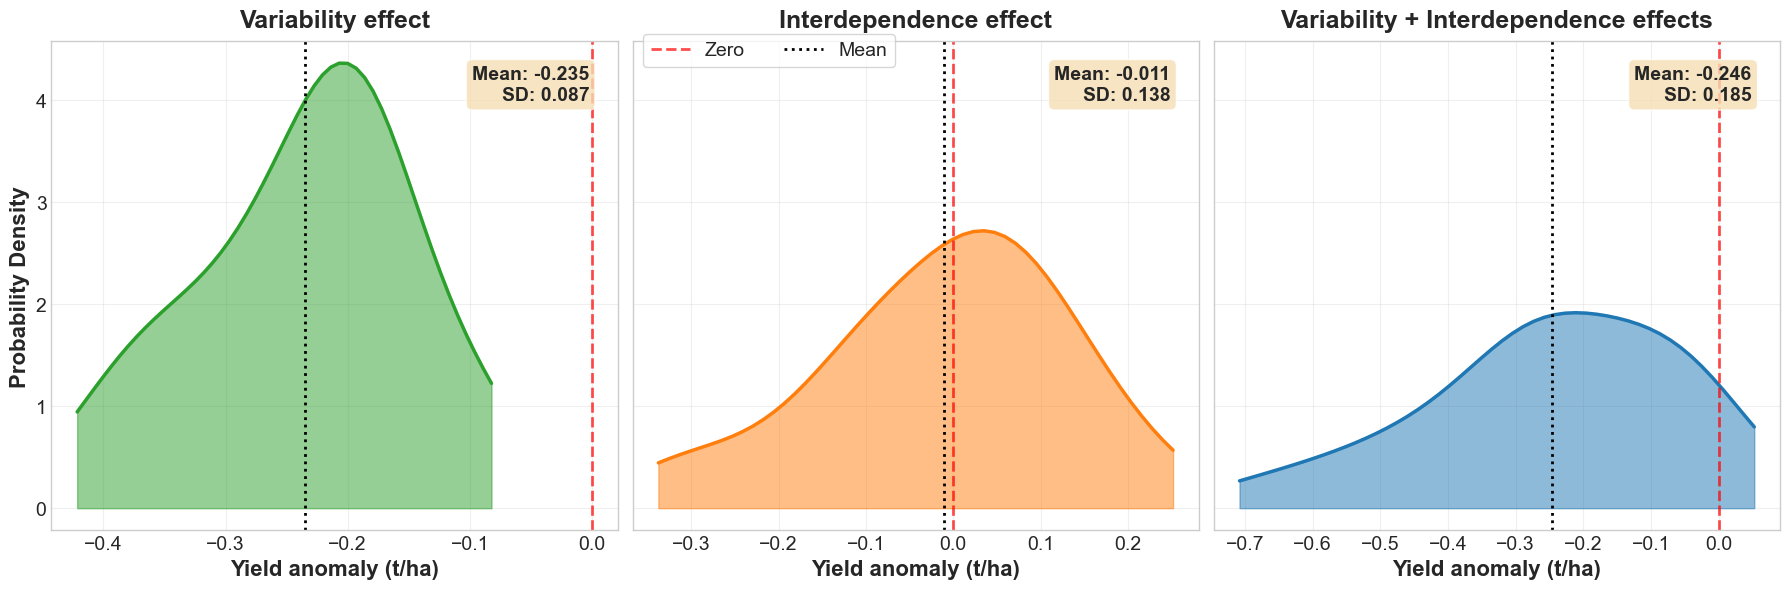


=== Summary Statistics ===

Variability effect:
  Mean: -0.2352 t/ha
  Median: -0.2195 t/ha
  Std Dev: 0.0882 t/ha
  Min: -0.4216 t/ha
  Max: -0.0822 t/ha
  N: 30

Interdependence effect:
  Mean: -0.0107 t/ha
  Median: 0.0100 t/ha
  Std Dev: 0.1401 t/ha
  Min: -0.3377 t/ha
  Max: 0.2517 t/ha
  N: 30

Variability + Interdependence effects:
  Mean: -0.2459 t/ha
  Median: -0.2480 t/ha
  Std Dev: 0.1881 t/ha
  Min: -0.7081 t/ha
  Max: 0.0527 t/ha
  N: 30


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")

def calculate_pdf(data, bins=50):
    """Calculate probability density function using kernel density estimation."""
    if len(data) < 2 or data.std() == 0:
        return np.array([data.mean()]), np.array([1.0])
    kde = stats.gaussian_kde(data, bw_method='scott')
    x_range = np.linspace(data.min(), data.max(), bins)
    pdf = kde(x_range)
    return x_range, pdf

# Load NorESM2-LM data
print("Loading NorESM2-LM data...")
df = pd.read_csv('/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-LM.csv')

print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")

# Filter for Northern Subtropics only
df_ns = df[df['region'] == 'R04_NS'].copy()

print(f"\nNorthern Subtropics data: {len(df_ns)} rows")

# Convert numeric columns
diff_cols = ['diff_M1_M2', 'diff_M2_M3', 'diff_M1_M3']
for col in diff_cols:
    if col in df_ns.columns:
        df_ns[col] = pd.to_numeric(df_ns[col], errors='coerce')

# Check data availability
print("\nYield difference columns:")
for col in diff_cols:
    if col in df_ns.columns:
        valid_data = df_ns[col].dropna()
        print(f"  {col}: {len(valid_data)} valid values, mean={valid_data.mean():.3f}, std={valid_data.std():.3f}")

# Create the PDF plot with shared y-axis
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Reordered sequence: Mean effect, Variability effect, Coupling effect
diff_configs = [
    {'col': 'diff_M1_M2', 'label': 'Variability effect', 'color': '#2ca02c'},
    {'col': 'diff_M2_M3', 'label': 'Interdependence effect', 'color': '#ff7f0e'},
    {'col': 'diff_M1_M3', 'label': 'Variability + Interdependence effects', 'color': '#1f77b4'}
]

# Store handles and labels for shared legend
legend_handles = []
legend_labels = []

for idx, diff_info in enumerate(diff_configs):
    ax = axes[idx]
    diff_col = diff_info['col']
    
    # Get data
    data = df_ns[diff_col].dropna().values
    
    if len(data) > 0:
        # Calculate PDF
        x, pdf = calculate_pdf(data)
        
        # Plot
        ax.fill_between(x, pdf, alpha=0.5, color=diff_info['color'])
        ax.plot(x, pdf, color=diff_info['color'], linewidth=2.5)
        
        # Add vertical line at zero
        line_zero = ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
        
        # Add mean line
        mean_val = data.mean()
        line_mean = ax.axvline(x=mean_val, color='black', linestyle=':', linewidth=2)
        
        # Collect legend handles only from the first subplot
        if idx == 0:
            legend_handles = [line_zero, line_mean]
            legend_labels = ['Zero', 'Mean']
        
        # Statistics text
        stats_text = f'Mean: {mean_val:.3f}\nSD: {data.std():.3f}'
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
               fontsize=14, fontweight='bold')
        
        # Formatting
        ax.set_title(diff_info['label'], fontsize=18, fontweight='bold', pad=10)
        ax.set_xlabel('Yield anomaly (t/ha)', fontsize=16, fontweight='bold')
        
        # Only set ylabel for the first subplot
        if idx == 0:
            ax.set_ylabel('Probability Density', fontsize=16, fontweight='bold')
        
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=14)
    else:
        ax.text(0.5, 0.5, 'No data available', 
               transform=ax.transAxes, ha='center', va='center', fontsize=14)

# Add single legend for the entire figure
fig.legend(legend_handles, legend_labels, loc='upper center', 
          bbox_to_anchor=(0.43, 0.95), ncol=2, fontsize=14, frameon=True)

plt.tight_layout()

# Save
output_file = 'NorESM2-LM_NorthernSubtropics1.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_file}")

plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
for diff_info in diff_configs:
    diff_col = diff_info['col']
    if diff_col in df_ns.columns:
        data = df_ns[diff_col].dropna()
        print(f"\n{diff_info['label']}:")
        print(f"  Mean: {data.mean():.4f} t/ha")
        print(f"  Median: {data.median():.4f} t/ha")
        print(f"  Std Dev: {data.std():.4f} t/ha")
        print(f"  Min: {data.min():.4f} t/ha")
        print(f"  Max: {data.max():.4f} t/ha")
        print(f"  N: {len(data)}")

Loading NorESM2-LM data...
Loaded 150 rows
Columns: ['region', 'year', 'E_mean', 'SM_mean', 'E_sd', 'SM_sd', 'dep_ESM', 'log_yield_M1', 'log_yield_M2', 'log_yield_M3', 'yield_M1', 'yield_M2', 'yield_M3', 'diff_M2_M3', 'diff_M1_M3', 'diff_M1_M2']

Northern Subtropics data: 30 rows

Yield difference columns:
  diff_M2_M3: 30 valid values, mean=-0.011, std=0.140
  diff_M1_M3: 30 valid values, mean=-0.246, std=0.188
  diff_M1_M2: 30 valid values, mean=-0.235, std=0.088

✓ Saved: NorESM2-LM_NorthernSubtropics.png


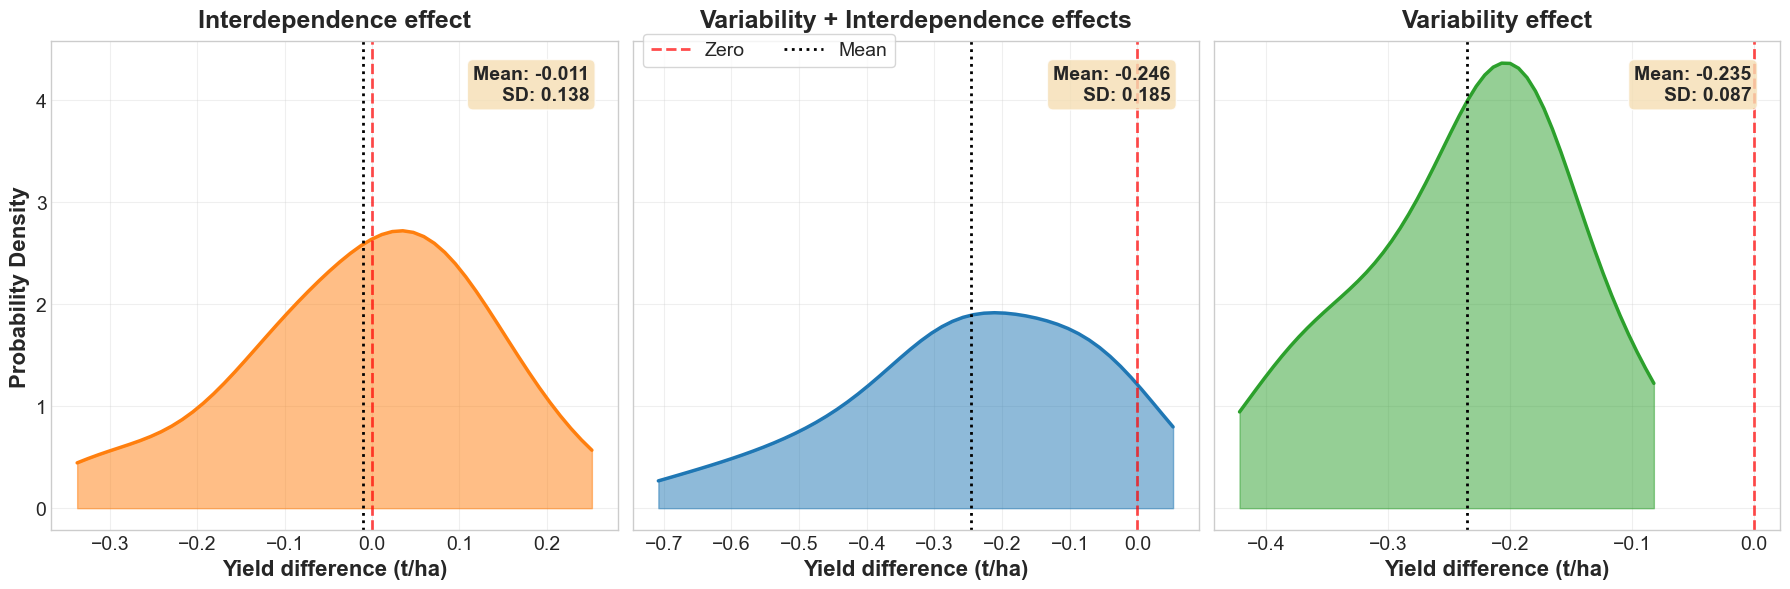


=== Summary Statistics ===

Interdependence effect:
  Mean: -0.0107 t/ha
  Median: 0.0100 t/ha
  Std Dev: 0.1401 t/ha
  Min: -0.3377 t/ha
  Max: 0.2517 t/ha
  N: 30

Variability + Interdependence effects:
  Mean: -0.2459 t/ha
  Median: -0.2480 t/ha
  Std Dev: 0.1881 t/ha
  Min: -0.7081 t/ha
  Max: 0.0527 t/ha
  N: 30

Variability effect:
  Mean: -0.2352 t/ha
  Median: -0.2195 t/ha
  Std Dev: 0.0882 t/ha
  Min: -0.4216 t/ha
  Max: -0.0822 t/ha
  N: 30


In [4]:
# Different sequence 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")

def calculate_pdf(data, bins=50):
    """Calculate probability density function using kernel density estimation."""
    if len(data) < 2 or data.std() == 0:
        return np.array([data.mean()]), np.array([1.0])
    kde = stats.gaussian_kde(data, bw_method='scott')
    x_range = np.linspace(data.min(), data.max(), bins)
    pdf = kde(x_range)
    return x_range, pdf

# Load NorESM2-LM data
print("Loading NorESM2-LM data...")
df = pd.read_csv('/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-LM.csv')

print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")

# Filter for Northern Subtropics only
df_ns = df[df['region'] == 'R04_NS'].copy()

print(f"\nNorthern Subtropics data: {len(df_ns)} rows")

# Convert numeric columns
diff_cols = ['diff_M2_M3', 'diff_M1_M3', 'diff_M1_M2']
for col in diff_cols:
    if col in df_ns.columns:
        df_ns[col] = pd.to_numeric(df_ns[col], errors='coerce')

# Check data availability
print("\nYield difference columns:")
for col in diff_cols:
    if col in df_ns.columns:
        valid_data = df_ns[col].dropna()
        print(f"  {col}: {len(valid_data)} valid values, mean={valid_data.mean():.3f}, std={valid_data.std():.3f}")

# Create the PDF plot with shared y-axis
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Reordered sequence: Mean effect, Variability effect, Coupling effect
diff_configs = [
    {'col': 'diff_M2_M3', 'label': 'Interdependence effect', 'color': '#ff7f0e'},
    {'col': 'diff_M1_M3', 'label': 'Variability + Interdependence effects', 'color': '#1f77b4'},
    {'col': 'diff_M1_M2', 'label': 'Variability effect', 'color': '#2ca02c'}
]

# Store handles and labels for shared legend
legend_handles = []
legend_labels = []

for idx, diff_info in enumerate(diff_configs):
    ax = axes[idx]
    diff_col = diff_info['col']
    
    # Get data
    data = df_ns[diff_col].dropna().values
    
    if len(data) > 0:
        # Calculate PDF
        x, pdf = calculate_pdf(data)
        
        # Plot
        ax.fill_between(x, pdf, alpha=0.5, color=diff_info['color'])
        ax.plot(x, pdf, color=diff_info['color'], linewidth=2.5)
        
        # Add vertical line at zero
        line_zero = ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
        
        # Add mean line
        mean_val = data.mean()
        line_mean = ax.axvline(x=mean_val, color='black', linestyle=':', linewidth=2)
        
        # Collect legend handles only from the first subplot
        if idx == 0:
            legend_handles = [line_zero, line_mean]
            legend_labels = ['Zero', 'Mean']
        
        # Statistics text
        stats_text = f'Mean: {mean_val:.3f}\nSD: {data.std():.3f}'
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
               fontsize=14, fontweight='bold')
        
        # Formatting
        ax.set_title(diff_info['label'], fontsize=18, fontweight='bold', pad=10)
        ax.set_xlabel('Yield difference (t/ha)', fontsize=16, fontweight='bold')
        
        # Only set ylabel for the first subplot
        if idx == 0:
            ax.set_ylabel('Probability Density', fontsize=16, fontweight='bold')
        
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=14)
    else:
        ax.text(0.5, 0.5, 'No data available', 
               transform=ax.transAxes, ha='center', va='center', fontsize=14)

# Add single legend for the entire figure
fig.legend(legend_handles, legend_labels, loc='upper center', 
          bbox_to_anchor=(0.43, 0.95), ncol=2, fontsize=14, frameon=True)

plt.tight_layout()

# Save
output_file = 'NorESM2-LM_NorthernSubtropics.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_file}")

plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
for diff_info in diff_configs:
    diff_col = diff_info['col']
    if diff_col in df_ns.columns:
        data = df_ns[diff_col].dropna()
        print(f"\n{diff_info['label']}:")
        print(f"  Mean: {data.mean():.4f} t/ha")
        print(f"  Median: {data.median():.4f} t/ha")
        print(f"  Std Dev: {data.std():.4f} t/ha")
        print(f"  Min: {data.min():.4f} t/ha")
        print(f"  Max: {data.max():.4f} t/ha")
        print(f"  N: {len(data)}")

Loading NorESM2-LM data...
Loaded 150 rows
Columns: ['region', 'year', 'E_mean', 'SM_mean', 'E_sd', 'SM_sd', 'dep_ESM', 'log_yield_M1', 'log_yield_M2', 'log_yield_M3', 'yield_M1', 'yield_M2', 'yield_M3', 'diff_M2_M3', 'diff_M1_M3', 'diff_M1_M2']

Northern Subtropics data: 30 rows

Yield difference columns:
  yield_M1: 30 valid values, mean=3.372, std=0.029
  yield_M2: 30 valid values, mean=3.607, std=0.104
  yield_M3: 30 valid values, mean=3.618, std=0.192

✓ Saved: NorESM2-LM_NorthernSubtropics.png


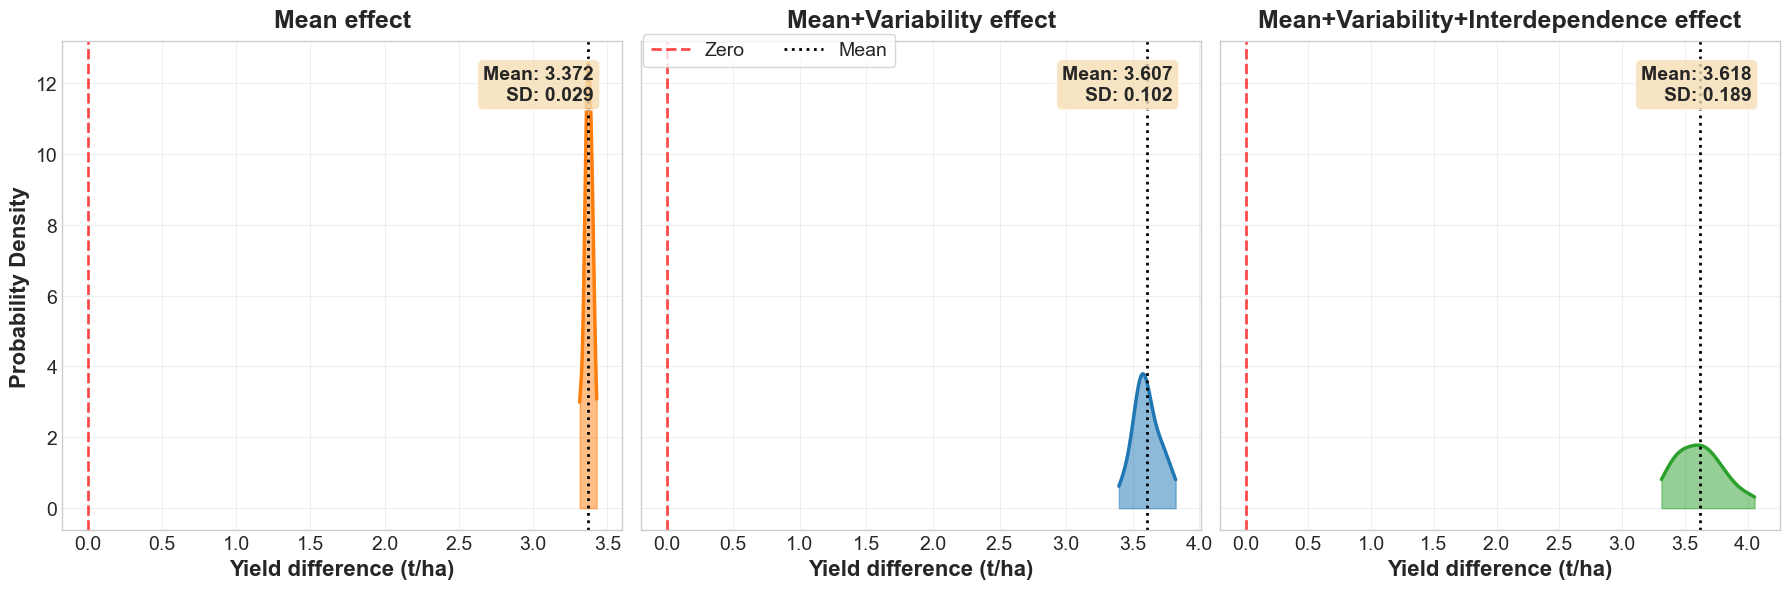


=== Summary Statistics ===

Mean effect:
  Mean: 3.3723 t/ha
  Median: 3.3703 t/ha
  Std Dev: 0.0295 t/ha
  Min: 3.3130 t/ha
  Max: 3.4275 t/ha
  N: 30

Mean+Variability effect:
  Mean: 3.6075 t/ha
  Median: 3.5940 t/ha
  Std Dev: 0.1036 t/ha
  Min: 3.3963 t/ha
  Max: 3.8224 t/ha
  N: 30

Mean+Variability+Interdependence effect:
  Mean: 3.6182 t/ha
  Median: 3.6254 t/ha
  Std Dev: 0.1922 t/ha
  Min: 3.3139 t/ha
  Max: 4.0560 t/ha
  N: 30


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")

def calculate_pdf(data, bins=50):
    """Calculate probability density function using kernel density estimation."""
    if len(data) < 2 or data.std() == 0:
        return np.array([data.mean()]), np.array([1.0])
    kde = stats.gaussian_kde(data, bw_method='scott')
    x_range = np.linspace(data.min(), data.max(), bins)
    pdf = kde(x_range)
    return x_range, pdf

# Load NorESM2-LM data
print("Loading NorESM2-LM data...")
df = pd.read_csv('/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-LM.csv')

print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")

# Filter for Northern Subtropics only
df_ns = df[df['region'] == 'R04_NS'].copy()

print(f"\nNorthern Subtropics data: {len(df_ns)} rows")

# Convert numeric columns
diff_cols = ['yield_M1', 'yield_M2', 'yield_M3']
for col in diff_cols:
    if col in df_ns.columns:
        df_ns[col] = pd.to_numeric(df_ns[col], errors='coerce')

# Check data availability
print("\nYield difference columns:")
for col in diff_cols:
    if col in df_ns.columns:
        valid_data = df_ns[col].dropna()
        print(f"  {col}: {len(valid_data)} valid values, mean={valid_data.mean():.3f}, std={valid_data.std():.3f}")

# Create the PDF plot with shared y-axis
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Reordered sequence: Mean effect, Variability effect, Coupling effect
diff_configs = [
    {'col': 'yield_M1', 'label': 'Mean effect', 'color': '#ff7f0e'},
    {'col': 'yield_M2', 'label': 'Mean+Variability effect', 'color': '#1f77b4'},
    {'col': 'yield_M3', 'label': 'Mean+Variability+Interdependence effect', 'color': '#2ca02c'}
]

# Store handles and labels for shared legend
legend_handles = []
legend_labels = []

for idx, diff_info in enumerate(diff_configs):
    ax = axes[idx]
    diff_col = diff_info['col']
    
    # Get data
    data = df_ns[diff_col].dropna().values
    
    if len(data) > 0:
        # Calculate PDF
        x, pdf = calculate_pdf(data)
        
        # Plot
        ax.fill_between(x, pdf, alpha=0.5, color=diff_info['color'])
        ax.plot(x, pdf, color=diff_info['color'], linewidth=2.5)
        
        # Add vertical line at zero
        line_zero = ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
        
        # Add mean line
        mean_val = data.mean()
        line_mean = ax.axvline(x=mean_val, color='black', linestyle=':', linewidth=2)
        
        # Collect legend handles only from the first subplot
        if idx == 0:
            legend_handles = [line_zero, line_mean]
            legend_labels = ['Zero', 'Mean']
        
        # Statistics text
        stats_text = f'Mean: {mean_val:.3f}\nSD: {data.std():.3f}'
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
               fontsize=14, fontweight='bold')
        
        # Formatting
        ax.set_title(diff_info['label'], fontsize=18, fontweight='bold', pad=10)
        ax.set_xlabel('Yield difference (t/ha)', fontsize=16, fontweight='bold')
        
        # Only set ylabel for the first subplot
        if idx == 0:
            ax.set_ylabel('Probability Density', fontsize=16, fontweight='bold')
        
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=14)
    else:
        ax.text(0.5, 0.5, 'No data available', 
               transform=ax.transAxes, ha='center', va='center', fontsize=14)

# Add single legend for the entire figure
fig.legend(legend_handles, legend_labels, loc='upper center', 
          bbox_to_anchor=(0.43, 0.95), ncol=2, fontsize=14, frameon=True)

plt.tight_layout()

# Save
output_file = 'NorESM2-LM_NorthernSubtropics.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_file}")

plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
for diff_info in diff_configs:
    diff_col = diff_info['col']
    if diff_col in df_ns.columns:
        data = df_ns[diff_col].dropna()
        print(f"\n{diff_info['label']}:")
        print(f"  Mean: {data.mean():.4f} t/ha")
        print(f"  Median: {data.median():.4f} t/ha")
        print(f"  Std Dev: {data.std():.4f} t/ha")
        print(f"  Min: {data.min():.4f} t/ha")
        print(f"  Max: {data.max():.4f} t/ha")
        print(f"  N: {len(data)}")

Loading NorESM2-LM data...
Loaded 150 rows
Columns: ['region', 'year', 'E_mean', 'SM_mean', 'E_sd', 'SM_sd', 'dep_ESM', 'log_yield_M1', 'log_yield_M2', 'log_yield_M3', 'yield_M1', 'yield_M2', 'yield_M3', 'diff_M2_M3', 'diff_M1_M3', 'diff_M1_M2']

Northern Subtropics data: 30 rows

Yield difference columns:
  diff_M1_M3: 30 valid values, mean=-0.246, std=0.188
  diff_M2_M3: 30 valid values, mean=-0.011, std=0.140
  diff_M1_M2: 30 valid values, mean=-0.235, std=0.088

✓ Saved: PDF_NorESM2-LM_NorthernSubtropics.png


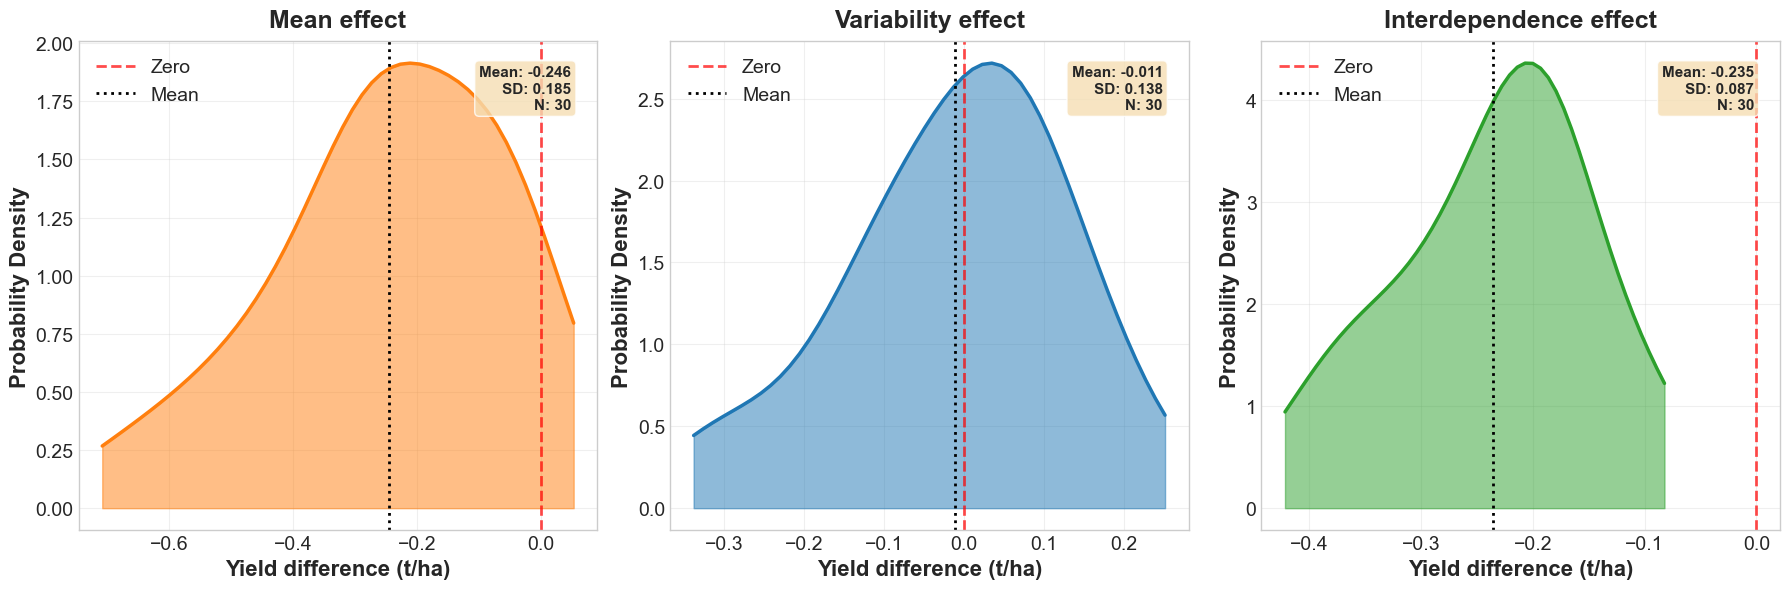


=== Summary Statistics ===

Mean effect:
  Mean: -0.2459 t/ha
  Median: -0.2480 t/ha
  Std Dev: 0.1881 t/ha
  Min: -0.7081 t/ha
  Max: 0.0527 t/ha
  N: 30

Variability effect:
  Mean: -0.0107 t/ha
  Median: 0.0100 t/ha
  Std Dev: 0.1401 t/ha
  Min: -0.3377 t/ha
  Max: 0.2517 t/ha
  N: 30

Interdependence effect:
  Mean: -0.2352 t/ha
  Median: -0.2195 t/ha
  Std Dev: 0.0882 t/ha
  Min: -0.4216 t/ha
  Max: -0.0822 t/ha
  N: 30


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")

def calculate_pdf(data, bins=50):
    """Calculate probability density function using kernel density estimation."""
    if len(data) < 2 or data.std() == 0:
        return np.array([data.mean()]), np.array([1.0])
    kde = stats.gaussian_kde(data, bw_method='scott')
    x_range = np.linspace(data.min(), data.max(), bins)
    pdf = kde(x_range)
    return x_range, pdf

# Load NorESM2-LM data
print("Loading NorESM2-LM data...")
df = pd.read_csv('/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-LM.csv')

print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")

# Filter for Northern Subtropics only
df_ns = df[df['region'] == 'R04_NS'].copy()

print(f"\nNorthern Subtropics data: {len(df_ns)} rows")

# Convert numeric columns
diff_cols = ['diff_M1_M3', 'diff_M2_M3', 'diff_M1_M2']
for col in diff_cols:
    if col in df_ns.columns:
        df_ns[col] = pd.to_numeric(df_ns[col], errors='coerce')

# Check data availability
print("\nYield difference columns:")
for col in diff_cols:
    if col in df_ns.columns:
        valid_data = df_ns[col].dropna()
        print(f"  {col}: {len(valid_data)} valid values, mean={valid_data.mean():.3f}, std={valid_data.std():.3f}")

# Create the PDF plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Reordered sequence: Mean effect, Variability effect, Coupling effect
diff_configs = [
    {'col': 'diff_M1_M3', 'label': 'Mean effect', 'color': '#ff7f0e'},
    {'col': 'diff_M2_M3', 'label': 'Variability effect', 'color': '#1f77b4'},
    {'col': 'diff_M1_M2', 'label': 'Interdependence effect', 'color': '#2ca02c'}
]

for idx, diff_info in enumerate(diff_configs):
    ax = axes[idx]
    diff_col = diff_info['col']
    
    # Get data
    data = df_ns[diff_col].dropna().values
    
    if len(data) > 0:
        # Calculate PDF
        x, pdf = calculate_pdf(data)
        
        # Plot
        ax.fill_between(x, pdf, alpha=0.5, color=diff_info['color'])
        ax.plot(x, pdf, color=diff_info['color'], linewidth=2.5)
        
        # Add vertical line at zero
        ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Zero')
        
        # Add mean line
        mean_val = data.mean()
        ax.axvline(x=mean_val, color='black', linestyle=':', linewidth=2, label='Mean')
        
        # Statistics text
        stats_text = f'Mean: {mean_val:.3f}\nSD: {data.std():.3f}\nN: {len(data)}'
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
               fontsize=11, fontweight='bold')
        
        # Formatting
        ax.set_title(diff_info['label'], fontsize=18, fontweight='bold', pad=10)
        ax.set_xlabel('Yield difference (t/ha)', fontsize=16, fontweight='bold')
        ax.set_ylabel('Probability Density', fontsize=16, fontweight='bold')
        ax.legend(fontsize=14, loc='upper left')
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=14)
    else:
        ax.text(0.5, 0.5, 'No data available', 
               transform=ax.transAxes, ha='center', va='center', fontsize=14)

plt.tight_layout()

# Save
output_file = 'PDF_NorESM2-LM_NorthernSubtropics.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_file}")

plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
for diff_info in diff_configs:
    diff_col = diff_info['col']
    if diff_col in df_ns.columns:
        data = df_ns[diff_col].dropna()
        print(f"\n{diff_info['label']}:")
        print(f"  Mean: {data.mean():.4f} t/ha")
        print(f"  Median: {data.median():.4f} t/ha")
        print(f"  Std Dev: {data.std():.4f} t/ha")
        print(f"  Min: {data.min():.4f} t/ha")
        print(f"  Max: {data.max():.4f} t/ha")
        print(f"  N: {len(data)}")

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from scipy.ndimage import gaussian_filter1d

# Set style for Nature-quality figures
plt.style.use('seaborn-v0_8-whitegrid')  # or just 'default'
sns.set_style("whitegrid")
sns.set_palette("husl")

# Define regions and colors
regions = {
    'R01_SM': {'name': 'Southern Mid-Lat', 'color': '#e41a1c'},
    'R02_SS': {'name': 'Southern Subtropics', 'color': '#377eb8'},
    'R03_Tropics': {'name': 'Tropics', 'color': '#4daf4a'},
    'R04_NS': {'name': 'Northern Subtropics', 'color': '#984ea3'},
    'R05_NM': {'name': 'Northern Mid-Lat', 'color': '#ff7f00'}
}

# CMIP6 models
models = ['MIROC6', 'NorESM2-LM', 'NorESM2-MM', 'CMCC-CM2-SR5', 'CMCC-ESM2']

# ============================================================================
# PART 1: Time Series Plots - Climate Variables and Yield by Region
# ============================================================================

def plot_climate_timeseries_per_region(df, output_file='climate_timeseries_by_region.png'):
    """
    Plot climate variables (mean, variability, coupling) and yield over time
    for each region in separate panels.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Must contain columns: region, year, E_mean, SM_mean, E_sd, SM_sd, 
                              dep_ESM, yield
    """
    fig, axes = plt.subplots(5, 1, figsize=(12, 18))
    fig.suptitle('Climate Drivers and Yield Response by Region (1981-2010)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    for idx, (region_code, region_info) in enumerate(regions.items()):
        ax_main = axes[idx]
        
        # Filter data for this region
        region_data = df[df['region'] == region_code].groupby('year', as_index=False).mean(numeric_only=True)
        
        if len(region_data) == 0:
            continue
        
        color = region_info['color']
        
        # Create twin axes for different scales
        ax_var = ax_main.twinx()
        
        # Plot means (solid lines)
        l1 = ax_main.plot(region_data['year'], region_data['E_mean'], 
                          color=color, linewidth=2.5, marker='o', markersize=4,
                          label='E mean', zorder=3)
        l2 = ax_main.plot(region_data['year'], region_data['SM_mean'], 
                          color='#2ca02c', linewidth=2.5, marker='o', markersize=4,
                          label='SM mean', zorder=3)
        
        # Plot variability (dashed lines)
        l3 = ax_var.plot(region_data['year'], region_data['E_sd'], 
                         color='#ff7f0e', linewidth=2.5, linestyle='--', 
                         marker='s', markersize=4, label='E variability', zorder=3)
        l4 = ax_var.plot(region_data['year'], region_data['SM_sd'], 
                         color='#9467bd', linewidth=2.5, linestyle='--', 
                         marker='s', markersize=4, label='SM variability', zorder=3)
        
        # Plot coupling as shaded area
        ax_main.fill_between(region_data['year'], 0, region_data['dep_ESM'], 
                             color='#8c564b', alpha=0.3, label='E-SM coupling', zorder=1)
        
        # Formatting
        ax_main.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax_main.set_ylabel('Mean / Coupling', fontsize=10, fontweight='bold')
        ax_var.set_ylabel('Variability', fontsize=10, fontweight='bold')
        ax_main.set_title(region_info['name'], fontsize=12, fontweight='bold', 
                         color=color, pad=10)
        
        # Combine legends
        lines = l1 + l2 + l3 + l4
        labels = [l.get_label() for l in lines]
        ax_main.legend(lines, labels, loc='upper left', fontsize=9, ncol=2)
        
        ax_main.grid(True, alpha=0.3)
        ax_main.tick_params(labelsize=9)
        ax_var.tick_params(labelsize=9)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_file}")
    plt.close()


def plot_climate_and_yield_separate(df, output_file='climate_yield_by_region.png'):
    """
    Plot climate variables in top panel and yield in bottom panel for each region.
    """
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(5, 2, hspace=0.3, wspace=0.3)
    
    fig.suptitle('Climate Drivers and Yield Response by Region', 
                 fontsize=16, fontweight='bold')
    
    for idx, (region_code, region_info) in enumerate(regions.items()):
        # Climate panel
        ax_climate = fig.add_subplot(gs[idx, 0])
        ax_var = ax_climate.twinx()
        
        # Yield panel
        ax_yield = fig.add_subplot(gs[idx, 1])
        
        # Filter data
        region_data = df[df['region'] == region_code].groupby('year', as_index=False).mean(numeric_only=True)
        
        if len(region_data) == 0:
            continue
        
        color = region_info['color']
        
        # Climate plot
        ax_climate.plot(region_data['year'], region_data['E_mean'], 
                       color=color, linewidth=2.5, marker='o', markersize=3,
                       label='E mean')
        ax_climate.plot(region_data['year'], region_data['SM_mean'], 
                       color='#2ca02c', linewidth=2.5, marker='o', markersize=3,
                       label='SM mean')
        
        ax_var.plot(region_data['year'], region_data['E_sd'], 
                   color='#ff7f0e', linewidth=2.5, linestyle='--', 
                   marker='s', markersize=3, label='E var')
        ax_var.plot(region_data['year'], region_data['SM_sd'], 
                   color='#9467bd', linewidth=2.5, linestyle='--', 
                   marker='s', markersize=3, label='SM var')
        
        ax_climate.fill_between(region_data['year'], 0, region_data['dep_ESM'], 
                               color='#8c564b', alpha=0.3, label='Coupling')
        
        # Yield plot
        ax_yield.plot(region_data['year'], region_data['yield'], 
                     color='#d62728', linewidth=3, marker='o', markersize=5)
        ax_yield.fill_between(region_data['year'], region_data['yield'], 
                             alpha=0.3, color='#d62728')
        
        # Formatting
        ax_climate.set_title(f"{region_info['name']} - Climate", 
                            fontweight='bold', color=color, fontsize=11)
        ax_yield.set_title(f"{region_info['name']} - Yield", 
                          fontweight='bold', color=color, fontsize=11)
        
        ax_climate.set_xlabel('Year', fontsize=10)
        ax_yield.set_xlabel('Year', fontsize=10)
        ax_climate.set_ylabel('Mean/Coupling', fontsize=9)
        ax_var.set_ylabel('Variability', fontsize=9)
        ax_yield.set_ylabel('Yield (t/ha)', fontsize=10, fontweight='bold')
        
        ax_climate.legend(fontsize=8, loc='upper left')
        ax_climate.grid(True, alpha=0.3)
        ax_yield.grid(True, alpha=0.3)
        ax_climate.tick_params(labelsize=8)
        ax_var.tick_params(labelsize=8)
        ax_yield.tick_params(labelsize=9)
    
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_file}")
    plt.close()


# ============================================================================
# PART 2: PDF Plots - Model Differences per Region
# ============================================================================

def calculate_pdf(data, bins=50):
    """Calculate probability density function using kernel density estimation."""
    if len(data) < 2 or data.std() == 0:
        return np.array([data.mean()]), np.array([1.0])
    kde = stats.gaussian_kde(data, bw_method='scott')
    x_range = np.linspace(data.min(), data.max(), bins)
    pdf = kde(x_range)
    return x_range, pdf

def plot_yield_difference_pdfs(df, output_file='yield_diff_pdfs_by_region.png'):
    """
    Plot PDFs of yield differences (M2-M3, M1-M3, M1-M2) for each region.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Must contain columns: region, diff_M2_M3, diff_M1_M3, diff_M1_M2
    """
    fig, axes = plt.subplots(5, 3, figsize=(15, 18))
    fig.suptitle('Probability Density Functions of Yield Differences by Region', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    diff_cols = {
        'diff_M2_M3': {'label': 'M2 - M3\n(Variability effect)', 'color': '#1f77b4'},
        'diff_M1_M3': {'label': 'M1 - M3\n(Mean effect)', 'color': '#ff7f0e'},
        'diff_M1_M2': {'label': 'M1 - M2\n(Coupling effect)', 'color': '#2ca02c'}
    }
    
    for row_idx, (region_code, region_info) in enumerate(regions.items()):
        region_data = df[df['region'] == region_code]
        
        if len(region_data) == 0:
            continue
        
        for col_idx, (diff_col, diff_info) in enumerate(diff_cols.items()):
            ax = axes[row_idx, col_idx]
            
            # Calculate PDF
            data = region_data[diff_col].dropna().values
            if len(data) > 0:
                x, pdf = calculate_pdf(data)
                
                # Plot
                ax.fill_between(x, pdf, alpha=0.5, color=diff_info['color'])
                ax.plot(x, pdf, color=diff_info['color'], linewidth=2)
                
                # Add vertical line at zero
                ax.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
                
                # Add mean line
                mean_val = data.mean()
                ax.axvline(x=mean_val, color='black', linestyle=':', linewidth=1.5)
                
                # Statistics text
                stats_text = f'Mean: {mean_val:.3f}\nSD: {data.std():.3f}'
                ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
                       verticalalignment='top', horizontalalignment='right',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                       fontsize=8)
            
            # Formatting
            if row_idx == 0:
                ax.set_title(diff_info['label'], fontsize=11, fontweight='bold')
            
            if col_idx == 0:
                ax.set_ylabel(f"{region_info['name']}\nDensity", 
                            fontsize=10, fontweight='bold', color=region_info['color'])
            else:
                ax.set_ylabel('Density', fontsize=9)
            
            if row_idx == 4:
                ax.set_xlabel('Yield difference (t/ha)', fontsize=10)
            
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=8)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_file}")
    plt.close()


# ============================================================================
# PART 3: Bivariate Plots with Marginal Distributions
# ============================================================================

def plot_bivariate_with_marginals(df, output_file='bivariate_marginals_by_region.png'):
    """
    Create bivariate plots with marginal distributions for each region.
    Shows: (a) E_mean vs SM_mean, (b) E_sd vs SM_sd, (c) dep_ESM vs SM_mean
    """
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(5, 3, hspace=0.35, wspace=0.3)
    
    fig.suptitle('Climate Variable Relationships by Region', 
                 fontsize=16, fontweight='bold')
    
    plot_configs = [
        {'x': 'E_mean', 'y': 'SM_mean', 'title': 'a  Shift in mean',
         'xlabel': 'E mean (mm/day)', 'ylabel': 'SM mean (m³/m³)'},
        {'x': 'E_sd', 'y': 'SM_sd', 'title': 'b  Increased variance',
         'xlabel': 'E variability (mm/day)', 'ylabel': 'SM variability (m³/m³)'},
        {'x': 'dep_ESM', 'y': 'SM_mean', 'title': 'c  Increased dependence',
         'xlabel': 'E-SM coupling', 'ylabel': 'SM mean (m³/m³)'}
    ]
    
    for row_idx, (region_code, region_info) in enumerate(regions.items()):
        region_data = df[df['region'] == region_code].dropna()
        
        if len(region_data) == 0:
            continue
        
        color = region_info['color']
        
        for col_idx, config in enumerate(plot_configs):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            
            x_data = region_data[config['x']]
            y_data = region_data[config['y']]
            z_data = region_data['yield']
            
            # Scatter plot with yield as size
            scatter = ax.scatter(x_data, y_data, c=z_data, s=50, 
                               alpha=0.6, cmap='viridis', edgecolors='black', linewidth=0.5)
            
            # Add colorbar for first column only
            if col_idx == 0:
                cbar = plt.colorbar(scatter, ax=ax)
                cbar.set_label('Yield (t/ha)', fontsize=8)
                cbar.ax.tick_params(labelsize=7)
            
            # Formatting
            if row_idx == 0:
                ax.set_title(config['title'], fontsize=11, fontweight='bold')
            
            if col_idx == 0:
                ax.text(-0.3, 0.5, region_info['name'], transform=ax.transAxes,
                       rotation=90, verticalalignment='center', fontsize=11,
                       fontweight='bold', color=color)
            
            ax.set_xlabel(config['xlabel'], fontsize=9)
            ax.set_ylabel(config['ylabel'], fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=8)
    
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_file}")
    plt.close()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # ========================================================================
    # Load future projections from 5 CMIP6 models
    # ========================================================================
    print("Loading future projections from 5 CMIP6 models...")
    
    # List your 5 model files here
    model_files = {
        'MIROC6': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_MIROC6.csv',
        'NorESM2-LM': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-LM.csv',
        'NorESM2-MM': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-MM.csv',
        'CMCC-CM2-SR5': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_CMCC-CM2-SR5.csv',
        'CMCC-ESM2': '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_CMCC-ESM2.csv'
    }
    
    # Load all models
    df_list = []
    for model_name, filepath in model_files.items():
        try:
            print(f"  Attempting to load: {filepath}")
            df_temp = pd.read_csv(filepath)
            df_temp['model'] = model_name  # Add model identifier
            df_list.append(df_temp)
            print(f"  ✓ Loaded {model_name}: {len(df_temp)} rows")
        except FileNotFoundError:
            print(f"  ✗ File not found: {filepath}")
        except Exception as e:
            print(f"  ✗ Error loading {filepath}: {str(e)}")
    
    if len(df_list) == 0:
        print("\n" + "="*70)
        print("ERROR: No model files were successfully loaded!")
        print("="*70)
        print("\nPlease check:")
        print("1. File paths are correct")
        print("2. Files exist in the specified location")
        print("3. You have read permissions")
        print("\nExpected files:")
        for model_name, filepath in model_files.items():
            print(f"  - {filepath}")
        print("\nCurrent working directory:", os.getcwd())
        exit(1)
    
    # Combine all models into one dataframe
    df_all_models = pd.concat(df_list, ignore_index=True)
    print(f"\nTotal combined data: {len(df_all_models)} rows from {len(df_list)} models")
    print(f"Columns in raw data: {list(df_all_models.columns)}")
    print(f"\nFirst few rows:")
    print(df_all_models.head(3))
    
    # Calculate ensemble mean by averaging across models for each region-year
    print("\nCalculating ensemble mean...")
    
    # Define the numeric columns we want to aggregate
    numeric_cols = ['E_mean', 'SM_mean', 'E_sd', 'SM_sd', 'dep_ESM',
                    'log_yield_M1', 'log_yield_M2', 'log_yield_M3',
                    'yield_M1', 'yield_M2', 'yield_M3',
                    'diff_M2_M3', 'diff_M1_M3', 'diff_M1_M2']
    
    # Check which columns actually exist and convert to numeric
    available_cols = []
    for col in numeric_cols:
        if col in df_all_models.columns:
            # Convert to numeric, coercing errors to NaN
            df_all_models[col] = pd.to_numeric(df_all_models[col], errors='coerce')
            available_cols.append(col)
    
    print(f"Available columns for aggregation: {available_cols}")
    print(f"Data types:\n{df_all_models[['region', 'year'] + available_cols].dtypes}")
    
    # Ensure year is numeric
    df_all_models['year'] = pd.to_numeric(df_all_models['year'], errors='coerce')

    # Remove any rows with NaN in grouping columns
    df_all_models = df_all_models.dropna(subset=['region', 'year'])

    # Verify data types before grouping
    print(f"\nData types before grouping:")
    print(f"  region: {df_all_models['region'].dtype}")
    print(f"  year: {df_all_models['year'].dtype}")
    print(f"  Sample numeric column: {df_all_models[available_cols[0]].dtype}")

    # Group by region and year, then calculate mean
    # Only include numeric columns in the aggregation
    df_ensemble = df_all_models.groupby(['region', 'year'], as_index=False)[available_cols].mean()

    print(f"\nAfter groupby:")
    print(f"  Shape: {df_ensemble.shape}")
    print(f"  Columns: {list(df_ensemble.columns)}")
    print(f"  Sample data:\n{df_ensemble.head()}")
    
    # Add a 'yield' column (using M3 as the full model with all effects)
    if 'yield_M3' in df_ensemble.columns:
        df_ensemble['yield'] = df_ensemble['yield_M3']
    if 'log_yield_M3' in df_ensemble.columns:
        df_ensemble['log_yield'] = df_ensemble['log_yield_M3']
    
    print(f"Ensemble mean data: {len(df_ensemble)} rows")
    print(f"Columns in ensemble data: {list(df_ensemble.columns)}")
    print(f"Regions: {df_ensemble['region'].unique()}")
    print(f"Year range: {df_ensemble['year'].min()} - {df_ensemble['year'].max()}")
    
    # Generate all plots
    print("\n=== Generating Plots ===\n")
    
    # Time series plots - using ensemble mean
    print("Generating time series plots...")
    plot_climate_timeseries_per_region(df_ensemble, 
                                       output_file='climate_timeseries_ensemble.png')
    plot_climate_and_yield_separate(df_ensemble, 
                                    output_file='climate_yield_ensemble.png')
    
    # PDF plots - using ensemble mean
    print("Generating PDF plots...")
    plot_yield_difference_pdfs(df_ensemble, 
                              output_file='yield_diff_pdfs_ensemble.png')
    
    # Bivariate plots - using ensemble mean
    print("Generating bivariate plots...")
    plot_bivariate_with_marginals(df_ensemble, 
                                  output_file='bivariate_marginals_ensemble.png')
    
    print("\n=== All ensemble plots generated successfully! ===")
    
    # Optional: Generate plots for each individual model
    print("\n=== Generating Individual Model Plots (Optional) ===\n")
    
    for model_name in model_files.keys():
        print(f"Processing {model_name}...")
        df_model = df_all_models[df_all_models['model'] == model_name].copy()
        df_model['yield'] = df_model['yield_M3']
        df_model['log_yield'] = df_model['log_yield_M3']
        
        # Generate plots for this model
        plot_climate_timeseries_per_region(df_model, 
                                          output_file=f'climate_timeseries_{model_name}.png')
        plot_yield_difference_pdfs(df_model, 
                                  output_file=f'yield_diff_pdfs_{model_name}.png')
    
    print("\n=== Individual model plots generated! ===")
    
    # Summary statistics
    print("\n=== Ensemble Mean Statistics by Region ===\n")
    for region_code, region_info in regions.items():
        print(f"\n{region_info['name']} ({region_code}):")
        region_data = df_ensemble[df_ensemble['region'] == region_code]
        if len(region_data) > 0:
            print(f"  Yield (M3): {region_data['yield_M3'].mean():.2f} ± {region_data['yield_M3'].std():.2f} t/ha")
            print(f"  E mean: {region_data['E_mean'].mean():.2f} ± {region_data['E_mean'].std():.2f} mm/day")
            print(f"  SM mean: {region_data['SM_mean'].mean():.3f} ± {region_data['SM_mean'].std():.3f} m³/m³")
            print(f"  E-SM coupling: {region_data['dep_ESM'].mean():.3f} ± {region_data['dep_ESM'].std():.3f}")
            print(f"  Diff M2-M3: {region_data['diff_M2_M3'].mean():.3f} ± {region_data['diff_M2_M3'].std():.3f}")
            print(f"  Diff M1-M3: {region_data['diff_M1_M3'].mean():.3f} ± {region_data['diff_M1_M3'].std():.3f}")
            print(f"  Diff M1-M2: {region_data['diff_M1_M2'].mean():.3f} ± {region_data['diff_M1_M2'].std():.3f}")
    
    # Model-specific statistics
    print("\n=== Statistics by Individual Model ===\n")
    for model_name in model_files.keys():
        model_data = df_all_models[df_all_models['model'] == model_name]
        if len(model_data) > 0:
            print(f"\n{model_name}:")
            print(f"  Mean yield (M3): {model_data['yield_M3'].mean():.2f} t/ha")
            print(f"  Mean diff M2-M3: {model_data['diff_M2_M3'].mean():.3f} t/ha")
            print(f"  Records: {len(model_data)}")
    
    print("\n=== Analysis Complete! ===")
    print("\nGenerated files:")
    print("  - climate_timeseries_ensemble.png")
    print("  - climate_yield_ensemble.png")
    print("  - yield_diff_pdfs_ensemble.png")
    print("  - bivariate_marginals_ensemble.png")
    print("  - Individual model plots (5 models × 2 plot types)")

    print("\n=== Plot files saved in: ===")
    print(os.path.abspath('.'))
    print("\nTo view plots, navigate to this directory and open the .png files")

Loading future projections from 5 CMIP6 models...
  Attempting to load: /Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_MIROC6.csv
  ✓ Loaded MIROC6: 150 rows
  Attempting to load: /Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-LM.csv
  ✓ Loaded NorESM2-LM: 150 rows
  Attempting to load: /Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-MM.csv
  ✓ Loaded NorESM2-MM: 150 rows
  Attempting to load: /Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_CMCC-CM2-SR5.csv
  ✓ Loaded CMCC-CM2-SR5: 150 rows
  Attempting to load: /Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_CMCC-ESM2.csv
  ✓ Loaded CMCC-ESM2: 150 rows

Total combined data: 750 rows from 5 models
Columns in raw data: ['region', 'year', 'E_mean', 'SM_mean', 'E_sd', 'SM_sd', 'dep_ESM', 'log_yield_M1', 'log_yield_M2', 'log_yield_M3', 'yield_M1', 'y